In [2]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
import os, time, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
 
warnings.filterwarnings('ignore')
os.makedirs('/kaggle/working/outputs', exist_ok=True)
 
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
 
# Enable mixed precision — doubles throughput on modern GPUs
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy().name)

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: mixed_float16


In [3]:
# ============================================================
# CELL 2 — Index All Images
# ============================================================
base_path = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
 
image_dirs = [
    os.path.join(base_path, folder, 'images')
    for folder in os.listdir(base_path)
    if folder.startswith('images_')
]
 
image_path_dict = {}
for d in image_dirs:
    if os.path.exists(d):
        for fname in os.listdir(d):
            image_path_dict[fname] = os.path.join(d, fname)
 
print(f"Total images indexed: {len(image_path_dict)}")
# Should print 112120 — if not, check your dataset path

Total images indexed: 112120


In [4]:
# ============================================================
# CELL 3 — Load CSV, Create Multi-Label Columns
# ============================================================
CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation',
    'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
]
NUM_CLASSES = len(CLASSES)
 
csv_path = os.path.join(base_path, 'Data_Entry_2017.csv')
df = pd.read_csv(csv_path)
 
for cls in CLASSES:
    df[cls] = df['Finding Labels'].apply(lambda x: 1 if cls in x else 0)
 
df['image_path'] = df['Image Index'].map(image_path_dict)
df = df.dropna(subset=['image_path'])
 
print(f"CSV shape: {df.shape}")
print(f"Missing paths: {df['image_path'].isna().sum()}")
print(f"\nDisease counts:\n{df[CLASSES].sum().sort_values(ascending=False)}")

CSV shape: (112120, 27)
Missing paths: 0

Disease counts:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


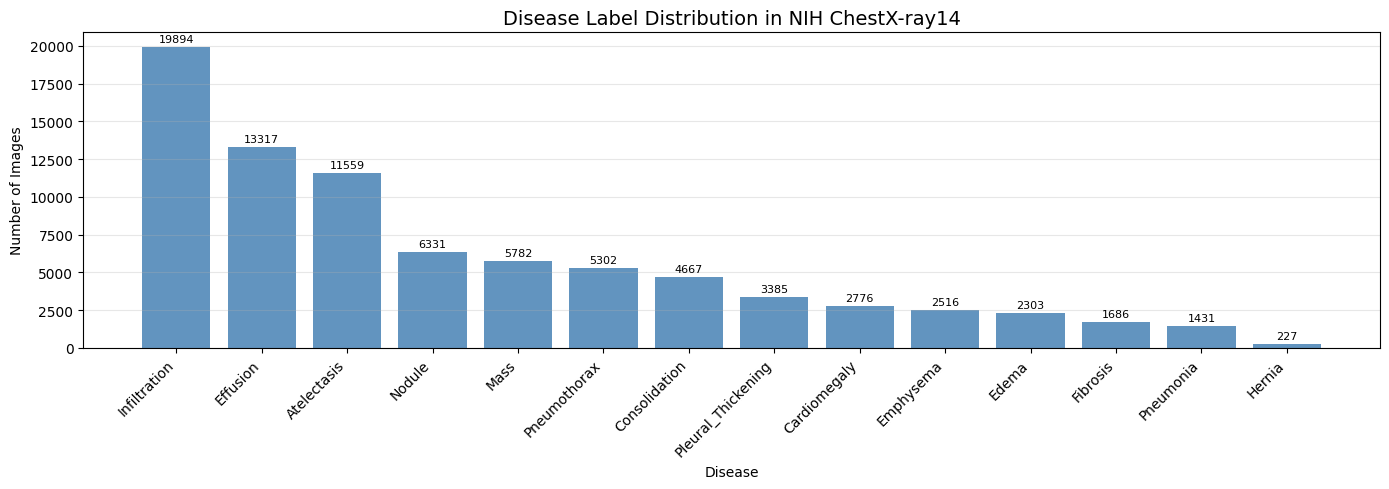

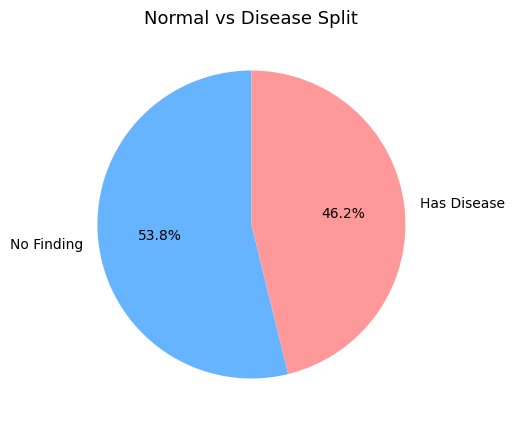

No Finding: 60361 (53.8%)
Has Disease: 51759 (46.2%)


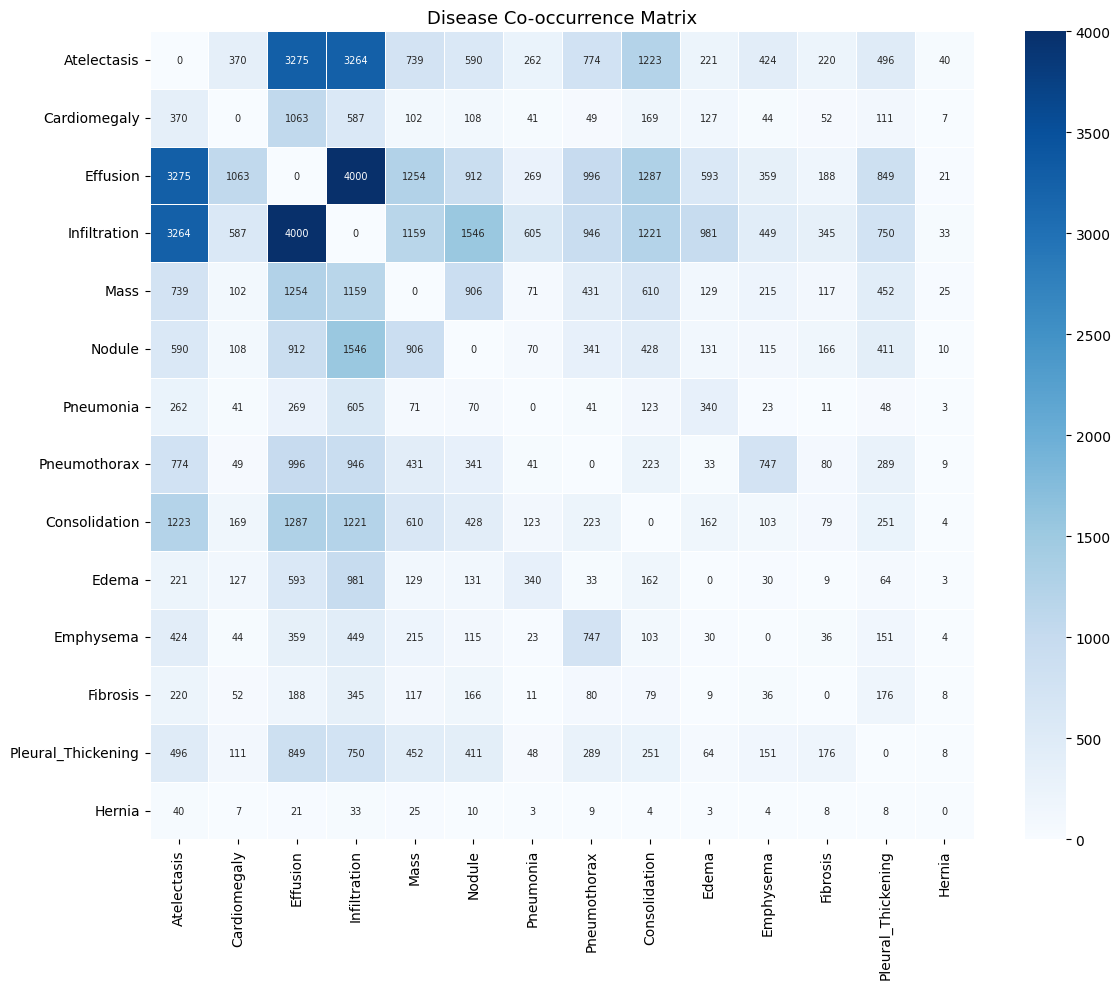

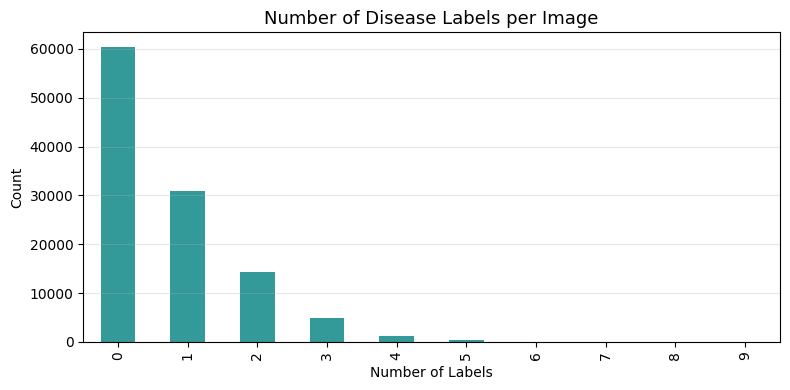

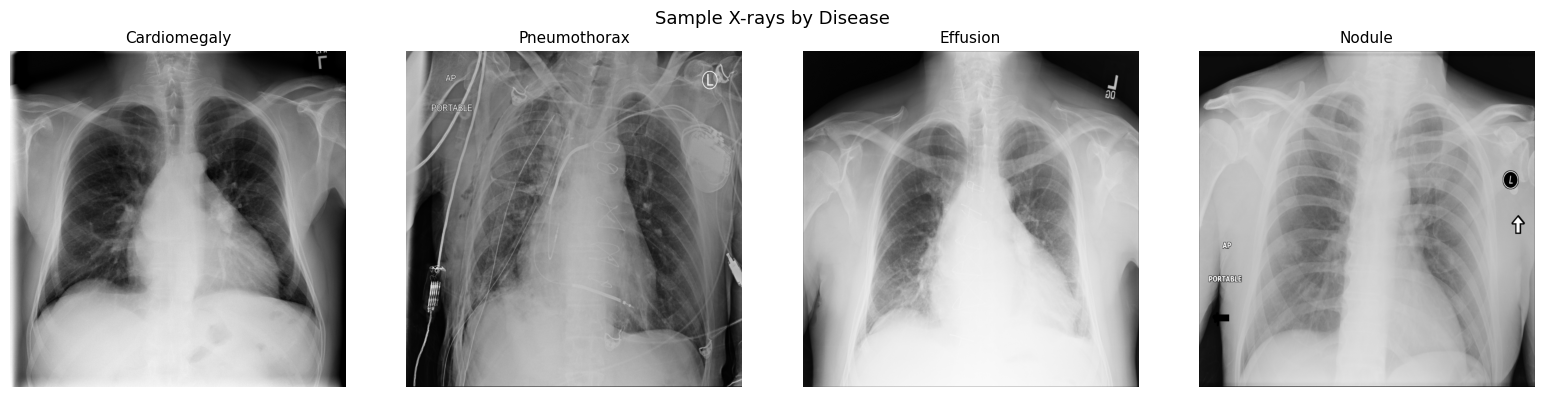

EDA complete. Plots saved.


In [19]:
# ============================================================
# EDA CELL — Add this after Cell 3
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Disease distribution bar chart
fig, ax = plt.subplots(figsize=(14, 5))
disease_counts = df[CLASSES].sum().sort_values(ascending=False)
bars = ax.bar(disease_counts.index, disease_counts.values, color='steelblue', alpha=0.85)
ax.set_title('Disease Label Distribution in NIH ChestX-ray14', fontsize=14)
ax.set_ylabel('Number of Images')
ax.set_xlabel('Disease')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, disease_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            str(int(val)), ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/disease_distribution.png', dpi=150)
plt.show()

# 2. No Finding vs Disease ratio
n_normal = (df['Finding Labels'] == 'No Finding').sum()
n_disease = len(df) - n_normal
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([n_normal, n_disease], labels=['No Finding', 'Has Disease'],
       autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
ax.set_title('Normal vs Disease Split', fontsize=13)
plt.savefig('/kaggle/working/outputs/normal_vs_disease.png', dpi=150)
plt.show()
print(f"No Finding: {n_normal} ({100*n_normal/len(df):.1f}%)")
print(f"Has Disease: {n_disease} ({100*n_disease/len(df):.1f}%)")

# 3. Multi-label co-occurrence heatmap
cooccurrence = df[CLASSES].T.dot(df[CLASSES])
np.fill_diagonal(cooccurrence.values, 0)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues',
            ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Disease Co-occurrence Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/cooccurrence_matrix.png', dpi=150)
plt.show()

# 4. Labels per image distribution
df['label_count'] = df[CLASSES].sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
df['label_count'].value_counts().sort_index().plot(kind='bar', ax=ax,
    color='teal', alpha=0.8)
ax.set_title('Number of Disease Labels per Image', fontsize=13)
ax.set_xlabel('Number of Labels')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/labels_per_image.png', dpi=150)
plt.show()

# 5. Sample images grid (4 diseases)
sample_diseases = ['Cardiomegaly', 'Pneumothorax', 'Effusion', 'Nodule']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, disease in zip(axes, sample_diseases):
    sample_row = df[df[disease] == 1].iloc[0]
    img = plt.imread(sample_row['image_path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(disease, fontsize=11)
    ax.axis('off')
plt.suptitle('Sample X-rays by Disease', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/sample_images.png', dpi=150)
plt.show()

print("EDA complete. Plots saved.")

In [5]:
# ============================================================
# CELL 4 — Patient-Level Split (NO data leakage)
# ============================================================
# CRITICAL: Same patient appears in multiple images.
# Random row-level split leaks patients across train/test.
# Always split on Patient ID.
 
patient_ids = df['Patient ID'].unique()
print(f"Total unique patients: {len(patient_ids)}")
 
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,    test_size=0.50, random_state=42)
 
train_df = df[df['Patient ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['Patient ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['Patient ID'].isin(test_ids)].reset_index(drop=True)
 
print(f"Train: {len(train_df):>6} images | {len(train_ids):>5} patients")
print(f"Val:   {len(val_df):>6} images | {len(val_ids):>5} patients")
print(f"Test:  {len(test_df):>6} images | {len(test_ids):>5} patients")
 
assert len(set(train_ids) & set(val_ids))  == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids)   & set(test_ids)) == 0
print("\nNo patient overlap confirmed.")

Total unique patients: 30805
Train:  78566 images | 21563 patients
Val:    17063 images |  4621 patients
Test:   16491 images |  4621 patients

No patient overlap confirmed.


In [6]:
# ============================================================
# CELL 5 — Dataset Pipeline
# ============================================================
IMG_SIZE   = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE
 
def load_and_preprocess(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.densenet.preprocess_input(img)
    return img, label
 
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.clip_by_value(image, -1.0, 1.0)
    return image, label
 
def make_dataset(dataframe, shuffle=False, augment_data=False):
    paths  = dataframe['image_path'].values
    labels = dataframe[CLASSES].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds
 
train_ds = make_dataset(train_df, shuffle=True,  augment_data=True)
val_ds   = make_dataset(val_df,   shuffle=False, augment_data=False)
test_ds  = make_dataset(test_df,  shuffle=False, augment_data=False)
 
print(f"Train batches: {len(train_ds)}")
print(f"Val   batches: {len(val_ds)}")
print(f"Test  batches: {len(test_ds)}")
 
# Quick sanity check on image range
for imgs, lbls in train_ds.take(1):
    print(f"\nImage shape : {imgs.shape}")
    print(f"Image range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
    print(f"Label shape : {lbls.shape}")
    print(f"Label sample: {lbls[0].numpy()}")
 

I0000 00:00:1778375963.297659      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778375963.304038      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train batches: 4911
Val   batches: 1067
Test  batches: 1031

Image shape : (16, 224, 224, 3)
Image range : [-1.00, 1.00]
Label shape : (16, 14)
Label sample: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.755946].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.6592865].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.603814].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.590461].
Clipping input data to the valid range for imshow with 

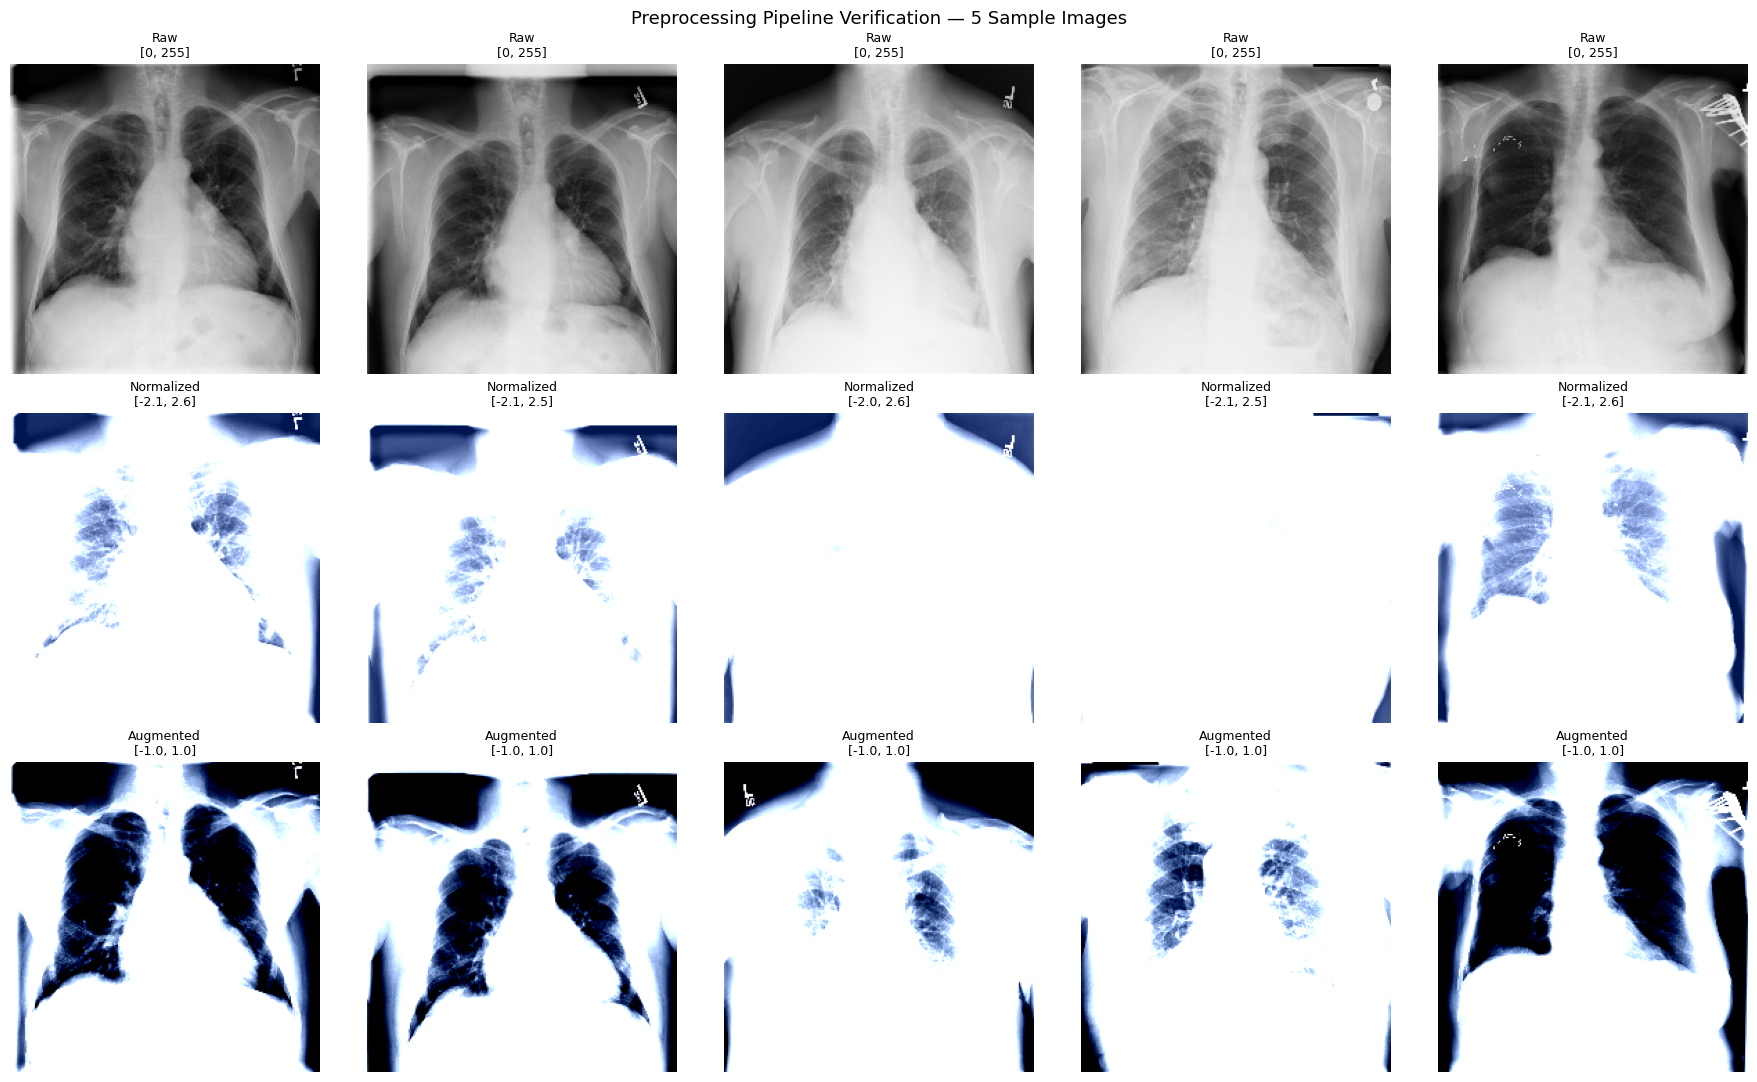

Preprocessing stats across one val batch:
  Shape         : (16, 224, 224, 3)
  Min / Max     : -2.118 / 2.640
  Mean / Std    : 0.444 / 1.149
  Expected range: roughly [-1.0, 2.5] for DenseNet preprocess_input
  Label dtype   : <dtype: 'float32'>  shape: (16, 14)

  Positive label rates per class (batch sample):
  Atelectasis           : 0.250  ███████
  Cardiomegaly          : 0.188  █████
  Effusion              : 0.062  █
  Infiltration          : 0.125  ███
  Mass                  : 0.062  █
  Nodule                : 0.125  ███
  Pneumonia             : 0.000  
  Pneumothorax          : 0.000  
  Consolidation         : 0.062  █
  Edema                 : 0.000  
  Emphysema             : 0.000  
  Fibrosis              : 0.000  
  Pleural_Thickening    : 0.062  █
  Hernia                : 0.000  


In [21]:
# ============================================================
# PREPROCESSING VERIFICATION CELL — Add after Cell 5 or Cell 14
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

# Row 0: Raw images (unnormalized, just resized)
# Row 1: Preprocessed (after DenseNet normalization)
# Row 2: Augmented training images

sample_paths = train_df['image_path'].values[:5]
IMG_SIZE = 224

for col, path in enumerate(sample_paths):
    # ── Raw ──────────────────────────────────────────────────
    raw = tf.io.read_file(path)
    raw = tf.image.decode_png(raw, channels=3)
    raw = tf.image.resize(raw, [IMG_SIZE, IMG_SIZE])
    raw_np = raw.numpy().astype('uint8')

    axes[0, col].imshow(raw_np, cmap='gray')
    axes[0, col].set_title(f'Raw\n[0, 255]', fontsize=9)
    axes[0, col].axis('off')

    # ── Preprocessed (normalized) ─────────────────────────────
    proc = tf.keras.applications.densenet.preprocess_input(
               tf.cast(raw, tf.float32))
    proc_np = proc.numpy()

    axes[1, col].imshow(proc_np - proc_np.min(),
                         cmap='gray')   # shift to [0,x] for display
    axes[1, col].set_title(
        f'Normalized\n[{proc_np.min():.1f}, {proc_np.max():.1f}]',
        fontsize=9)
    axes[1, col].axis('off')

    # ── Augmented ─────────────────────────────────────────────
    aug, _ = augment(proc, tf.zeros(14))
    aug_np = aug.numpy()

    axes[2, col].imshow(aug_np - aug_np.min(), cmap='gray')
    axes[2, col].set_title(
        f'Augmented\n[{aug_np.min():.1f}, {aug_np.max():.1f}]',
        fontsize=9)
    axes[2, col].axis('off')

# Row labels
for row, label in enumerate(['Raw', 'Normalized', 'Augmented']):
    axes[row, 0].set_ylabel(label, fontsize=12, fontweight='bold',
                             rotation=0, labelpad=60, va='center')

plt.suptitle('Preprocessing Pipeline Verification — 5 Sample Images',
             fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/preprocessing_verification.png', dpi=150)
plt.show()

# ── Numeric summary ───────────────────────────────────────────
print("Preprocessing stats across one val batch:")
for imgs, lbls in val_ds.take(1):
    imgs_np = imgs.numpy()
    print(f"  Shape         : {imgs_np.shape}")
    print(f"  Min / Max     : {imgs_np.min():.3f} / {imgs_np.max():.3f}")
    print(f"  Mean / Std    : {imgs_np.mean():.3f} / {imgs_np.std():.3f}")
    print(f"  Expected range: roughly [-1.0, 2.5] for DenseNet preprocess_input")
    print(f"  Label dtype   : {lbls.dtype}  shape: {lbls.shape}")
    positive_rate = lbls.numpy().mean(axis=0)
    print("\n  Positive label rates per class (batch sample):")
    for cls, rate in zip(CLASSES, positive_rate):
        bar = '█' * int(rate * 30)
        print(f"  {cls:<22}: {rate:.3f}  {bar}")

In [7]:
# ============================================================
# CELL 6 — Class Weights & Loss Function
# ============================================================

total = len(train_df)
pos_weights_raw = []
for cls in CLASSES:
    pos = train_df[cls].sum()
    neg = total - pos
    pos_weights_raw.append(neg / (pos + 1e-7))

# Square root scaling — reduces extreme weights (496 → 22)
# Raw ratio weights blow up the loss for rare classes like Hernia
pos_weights_scaled = [min(np.sqrt(w), 20.0) for w in pos_weights_raw]
pos_weights_tensor = tf.constant(pos_weights_scaled, dtype=tf.float32)

print("Class weights (sqrt-scaled, capped at 20):")
for cls, raw, scaled in zip(CLASSES, pos_weights_raw, pos_weights_scaled):
    print(f"  {cls:<22}: raw={raw:>6.1f}  scaled={scaled:>5.2f}")


class WeightedBCE(tf.keras.losses.Loss):
    """
    Weighted Binary Cross-Entropy with label smoothing.
    Uses sqrt-scaled class weights to prevent loss explosion
    on rare classes (Hernia, Pneumonia, Fibrosis).
    """
    def __init__(self, pos_weights, label_smoothing=0.05):
        super().__init__()
        self.pos_weights     = pos_weights
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Label smoothing
        y_smooth = y_true * (1.0 - self.label_smoothing) \
                 + 0.5   *         self.label_smoothing

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Standard BCE
        bce = -(
            y_smooth         * tf.math.log(y_pred) +
            (1.0 - y_smooth) * tf.math.log(1.0 - y_pred)
        )

        # Apply weights ONLY to positive samples
        # Negative samples keep weight = 1.0
        # This prevents rare-class weights from dominating
        weight_matrix = tf.where(
            y_true > 0.5,
            tf.ones_like(y_true) * self.pos_weights,
            tf.ones_like(y_true)
        )
        bce = bce * weight_matrix

        return tf.reduce_mean(bce)


loss_fn = WeightedBCE(pos_weights=pos_weights_tensor, label_smoothing=0.05)
print("\nWeightedBCE loss ready.")

# Sanity check — should now be 0.1–0.5
for imgs, lbls in val_ds.take(1):
    dummy_pred = tf.ones((lbls.shape[0], NUM_CLASSES), dtype=tf.float32) * 0.1
    test_loss  = loss_fn(lbls, dummy_pred).numpy()
    print(f"Sanity check loss (pred=0.1): {test_loss:.4f}  (should be 0.1–0.5)")

    dummy_pred2 = tf.ones((lbls.shape[0], NUM_CLASSES), dtype=tf.float32) * 0.5
    test_loss2  = loss_fn(lbls, dummy_pred2).numpy()
    print(f"Sanity check loss (pred=0.5): {test_loss2:.4f}  (should be 0.3–0.8)")

Class weights (sqrt-scaled, capped at 20):
  Atelectasis           : raw=   8.6  scaled= 2.93
  Cardiomegaly          : raw=  40.5  scaled= 6.37
  Effusion              : raw=   7.3  scaled= 2.71
  Infiltration          : raw=   4.7  scaled= 2.16
  Mass                  : raw=  17.4  scaled= 4.18
  Nodule                : raw=  16.7  scaled= 4.09
  Pneumonia             : raw=  78.0  scaled= 8.83
  Pneumothorax          : raw=  19.8  scaled= 4.45
  Consolidation         : raw=  23.3  scaled= 4.83
  Edema                 : raw=  47.2  scaled= 6.87
  Emphysema             : raw=  46.2  scaled= 6.79
  Fibrosis              : raw=  67.0  scaled= 8.18
  Pleural_Thickening    : raw=  32.0  scaled= 5.66
  Hernia                : raw= 496.3  scaled=20.00

WeightedBCE loss ready.
Sanity check loss (pred=0.1): 0.7586  (should be 0.1–0.5)
Sanity check loss (pred=0.5): 0.8346  (should be 0.3–0.8)


In [14]:
# ============================================================
# CELL 7 — Build Model  (DenseNet121 — same backbone as CheXNet)
# ============================================================
def build_model(num_classes=14):
    base = tf.keras.applications.DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False   # frozen for Phase 1
 
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.BatchNormalization(name='head_bn')(x)
    x = tf.keras.layers.Dropout(0.5, name='drop1')(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='fc1')(x)
    x = tf.keras.layers.BatchNormalization(name='fc_bn')(x)
    x = tf.keras.layers.Dropout(0.3, name='drop2')(x)
    # Use float32 for final layer even with mixed precision
    outputs = tf.keras.layers.Dense(
        num_classes, activation='sigmoid',
        dtype='float32', name='predictions'
    )(x)
 
    model = tf.keras.Model(inputs, outputs, name='CheXNet_DenseNet121')
    return model, base
 
 
model, base_model = build_model()
model.summary(line_length=80)
print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
print(f"Base layers      : {len(base_model.layers)}")

Model: "CheXNet_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ densenet121 (Functional)          │ (None, 7, 7, 1024)       │     7,037,504 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)      │ (None, 1024)             │         4,096 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop1 (Dropout)                   │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc1 (Dense)                       │ (None, 512)              │       524,800 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ fc_bn (BatchNormalization)        │ (None, 512)              │         2,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop2 (Dropout)                   │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 14)               │         7,182 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 7,575,630 (28.90 MB)

 Trainable params: 535,054 (2.04 MB)

 Non-trainable params: 7,040,576 (26.86 MB)


Total params     : 7,575,630
Trainable params : 535,054
Base layers      : 427


In [16]:
# ============================================================
# CELL 8 — PHASE 1: Train Head Only (base frozen)
#           Target: Val AUC > 0.72 before Phase 2
# ============================================================
optimizer_p1 = tf.keras.optimizers.Adam(learning_rate=1e-3)
 
train_loss_m = tf.keras.metrics.Mean(name='train_loss')
val_loss_m   = tf.keras.metrics.Mean(name='val_loss')
val_auc_m    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)
 
@tf.function
def train_step_p1(images, labels):
    with tf.GradientTape() as tape:
        preds = model(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = loss_fn(labels, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer_p1.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_m.update_state(loss)
 
@tf.function
def val_step(images, labels):
    preds = model(images, training=False)
    preds = tf.cast(preds, tf.float32)
    loss  = loss_fn(labels, preds)
    val_loss_m.update_state(loss)
    val_auc_m.update_state(labels, preds)
 
P1_EPOCHS = 5
best_auc   = 0.0
history    = {'train_loss': [], 'val_loss': [], 'val_auc': []}
 
print("PHASE 1 — Head training (base frozen)")
print(f"Epochs: {P1_EPOCHS}  |  LR: 1e-3")
print("Expected: val loss ~0.10–0.20, val AUC > 0.70 by epoch 3")
print("=" * 65)
 
for epoch in range(P1_EPOCHS):
    t0 = time.time()
    train_loss_m.reset_state()
    val_loss_m.reset_state()
    val_auc_m.reset_state()
 
    for step, (imgs, lbls) in enumerate(train_ds):
        train_step_p1(imgs, lbls)
        if step % 300 == 0:
            print(f"  ep{epoch+1} step {step:>4}/{len(train_ds)} "
                  f"| loss {train_loss_m.result():.4f}")
 
    for imgs, lbls in val_ds:
        val_step(imgs, lbls)
 
    tl = train_loss_m.result().numpy()
    vl = val_loss_m.result().numpy()
    va = val_auc_m.result().numpy()
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_auc'].append(va)
 
    print(f"\nEpoch {epoch+1}/{P1_EPOCHS}  train_loss={tl:.4f}  "
          f"val_loss={vl:.4f}  val_auc={va:.4f}  "
          f"time={time.time()-t0:.0f}s")
 
    model.save(f'/kaggle/working/outputs/p1_ep{epoch+1}.keras')
 
    if va > best_auc:
        best_auc = va
        model.save('/kaggle/working/outputs/best_p1.keras')
        print(f"  ✓ best Phase 1 model saved  (AUC {best_auc:.4f})")
 
    # Abort early if loss is exploding — means pipeline issue
    if vl > 2.0:
        print(f"\n  ✗ ABORT: val_loss={vl:.4f} > 2.0")
        print("  Check CELL 5 image preprocessing — wrong preprocess_input call?")
        break
 
    print("-" * 65)
 
print(f"\nPhase 1 done.  Best val AUC: {best_auc:.4f}")
if best_auc < 0.68:
    print("\n  ⚠  AUC below 0.68 after Phase 1.")
    print("  DO NOT run Phase 2 yet.")
    print("  Run CELL 5-DIAGNOSTIC before continuing.")
else:
    print("  ✓  Phase 1 healthy — safe to run Phase 2.")

PHASE 1 — Head training (base frozen)
Epochs: 5  |  LR: 1e-3
Expected: val loss ~0.10–0.20, val AUC > 0.70 by epoch 3
  ep1 step    0/4911 | loss 0.5049
  ep1 step  300/4911 | loss 0.5931
  ep1 step  600/4911 | loss 0.5710
  ep1 step  900/4911 | loss 0.5657
  ep1 step 1200/4911 | loss 0.5561
  ep1 step 1500/4911 | loss 0.5513
  ep1 step 1800/4911 | loss 0.5484
  ep1 step 2100/4911 | loss 0.5452
  ep1 step 2400/4911 | loss 0.5428
  ep1 step 2700/4911 | loss 0.5394
  ep1 step 3000/4911 | loss 0.5379
  ep1 step 3300/4911 | loss 0.5357
  ep1 step 3600/4911 | loss 0.5342
  ep1 step 3900/4911 | loss 0.5324
  ep1 step 4200/4911 | loss 0.5307
  ep1 step 4500/4911 | loss 0.5305
  ep1 step 4800/4911 | loss 0.5296

Epoch 1/5  train_loss=0.5293  val_loss=0.5227  val_auc=0.7009  time=727s
  ✓ best Phase 1 model saved  (AUC 0.7009)
-----------------------------------------------------------------
  ep2 step    0/4911 | loss 0.4605
  ep2 step  300/4911 | loss 0.5014
  ep2 step  600/4911 | loss 0.5025

In [ ]:
# ============================================================
# CELL 8B — DIAGNOSTIC (run this if Phase 1 AUC < 0.68)
#            Skip if Phase 1 was fine.
# ============================================================

''''print("=" * 65)
print("DIAGNOSTIC — run this if Phase 1 AUC looked wrong")
print("=" * 65)
 
# 1. Image range check
for imgs, lbls in val_ds.take(1):
    print(f"Image range: [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]")
    print("Expected for DenseNet: roughly [-1.0, 2.5]")
    print("If range is [0,255] → preprocessing not applied")
    print("If range is [-2.1,2.6] → EfficientNet preprocess used, switch to densenet")
 
# 2. Prediction distribution
for imgs, lbls in val_ds.take(1):
    preds = model(imgs, training=False).numpy()
    print(f"\nPrediction mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    print("If all predictions are ~0.5 → model output is stuck (vanishing gradient)")
    print("If all predictions are ~0.0 → model predicting all-negative (class imbalance)")
    for i, cls in enumerate(CLASSES):
        print(f"  {cls:<22}  pred={preds[0,i]:.3f}  true={lbls.numpy()[0,i]:.0f}")
 
# 3. Label distribution
print("\nDisease prevalence in val set:")
for cls in CLASSES:
    p = val_df[cls].mean()
    print(f"  {cls:<22}: {p:.4f}")''

In [17]:
# ============================================================
# CELL 9 — PHASE 2: Gradual Fine-Tuning
#           Loads BEST Phase 1 model explicitly.
#           Unfreeze schedule: top-60 → top-200 → all layers
# ============================================================
 
# ── Safety gate ───────────────────────────────────────────────────────────────
if best_auc < 0.68:
    raise RuntimeError(
        f"Phase 1 AUC = {best_auc:.4f}. "
        "Fix Phase 1 before running Phase 2."
    )
 
# ── ALWAYS load best Phase 1 checkpoint explicitly ───────────────────────────
# Never use the model object in memory — its state may be from a non-best epoch
print("Loading best Phase 1 weights...")
model = tf.keras.models.load_model(
    '/kaggle/working/outputs/best_p1.keras',
    custom_objects={'WeightedBCE': WeightedBCE},
    compile=False
)
base_model = model.get_layer('densenet121')

# Reduce dropout for smoother fine-tuning
model.get_layer('drop1').rate = 0.3
model.get_layer('drop2').rate = 0.2
 
# Verify it loaded correctly
for imgs, lbls in val_ds.take(1):
    preds = model(imgs, training=False).numpy()
    print(f"Loaded model — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    print("(std should be > 0.05, mean should be < 0.20)")
 
# ── Gradual unfreeze helper ───────────────────────────────────────────────────
def set_unfreeze(base, n_layers):
    """Unfreeze only the last n_layers of base. Rest stay frozen."""
    base.trainable = True
    for layer in base.layers[:-n_layers]:
        layer.trainable = False
    n_trainable = sum(1 for l in base.layers if l.trainable)
    print(f"  Unfrozen {n_trainable}/{len(base.layers)} base layers")
 
# Unfreeze schedule: epoch → how many layers to unfreeze
# Start conservative, open up gradually
UNFREEZE_SCHEDULE = {
    1:  60,
    6:  120,   # top 2 dense blocks only
    16: 200,   # add block 3
    24: 300    # full unfreeze late
}
 
# ── LR schedule ───────────────────────────────────────────────────────────────
NUM_EPOCHS_P2 = 35
total_steps   = NUM_EPOCHS_P2 * len(train_ds)
warmup_steps  = 3 * len(train_ds)   # 3 epoch warmup
 
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)
 
    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)
 
    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}
 
lr_schedule = WarmupCosineDecay(
    peak_lr      = 2e-5,    # higher than before — DenseNet is more stable
    total_steps  = total_steps,
    warmup_steps = warmup_steps
)
optimizer_p2 = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)
 
# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_m2 = tf.keras.metrics.Mean(name='train_loss')
val_loss_m2   = tf.keras.metrics.Mean(name='val_loss')
val_auc_m2    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)
 
@tf.function
def train_step_p2(images, labels):
    with tf.GradientTape() as tape:
        preds = model(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = loss_fn(labels, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer_p2.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_m2.update_state(loss)
 
@tf.function
def val_step2(images, labels):
    preds = model(images, training=False)
    preds = tf.cast(preds, tf.float32)
    loss  = loss_fn(labels, preds)
    val_loss_m2.update_state(loss)
    val_auc_m2.update_state(labels, preds)
 
# ── State ─────────────────────────────────────────────────────────────────────
best_auc_p2        = best_auc
no_improve         = 0
patience           = 10
p2_train_loss_hist = []
p2_val_loss_hist   = []
p2_val_auc_hist    = []
current_unfreeze   = 0
 
print(f"\nPHASE 2 — Gradual fine-tuning")
print(f"Epochs: {NUM_EPOCHS_P2}  |  Peak LR: 2e-5  |  Patience: {patience}")
print(f"Unfreeze: top-60 → top-120 → top-200 → top-300")
print("=" * 65)
 
for epoch in range(NUM_EPOCHS_P2):
    # Apply unfreeze schedule
    for start_ep in sorted(UNFREEZE_SCHEDULE.keys(), reverse=True):
        if epoch + 1 >= start_ep:
            new_unfreeze = UNFREEZE_SCHEDULE[start_ep]
            break

    if new_unfreeze != current_unfreeze:
        print(f"\n  → Unfreeze update at epoch {epoch+1}:")
        set_unfreeze(base_model, new_unfreeze)
        current_unfreeze = new_unfreeze
    
        # Reset patience after unfreeze
        no_improve = 0
 
    t0 = time.time()
    train_loss_m2.reset_state()
    val_loss_m2.reset_state()
    val_auc_m2.reset_state()
 
    for step, (imgs, lbls) in enumerate(train_ds):
        train_step_p2(imgs, lbls)
        if step % 300 == 0:
            lr_now = lr_schedule(optimizer_p2.iterations).numpy()
            print(f"  ep{epoch+1} step {step:>4}/{len(train_ds)} "
                  f"| loss {train_loss_m2.result():.4f} "
                  f"| lr {lr_now:.2e}")
 
    for imgs, lbls in val_ds:
        val_step2(imgs, lbls)
 
    tl = train_loss_m2.result().numpy()
    vl = val_loss_m2.result().numpy()
    va = val_auc_m2.result().numpy()
 
    p2_train_loss_hist.append(tl)
    p2_val_loss_hist.append(vl)
    p2_val_auc_hist.append(va)
 
    elapsed = time.time() - t0
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_P2}  "
          f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
          f"val_auc={va:.4f}  time={elapsed:.0f}s")
 
    # Warn if val loss explodes
    if vl > 1.0:
        print(f"  ⚠  val_loss={vl:.4f} is high — check if unfreeze is too aggressive")
 
    # Save periodic checkpoints only
    if (epoch + 1) % 5 == 0:
        model.save(f'/kaggle/working/outputs/p2_ep{epoch+1}.keras')
 
    if va > best_auc_p2:
        best_auc_p2 = va
        no_improve  = 0
        model.save('/kaggle/working/outputs/best_model_final.keras')
        print(f"  ✓ Best model saved  (AUC {best_auc_p2:.4f})")
    else:
        no_improve += 1
        print(f"  no improve {no_improve}/{patience}  (best {best_auc_p2:.4f})")
        if no_improve >= patience:
            print(f"\n  ⏹  Early stopping at epoch {epoch+1}")
            break
 
    print("-" * 65)
 
print(f"\nPhase 2 done.  Best val AUC: {best_auc_p2:.4f}")

Loading best Phase 1 weights...
Loaded model — pred mean: 0.1257  std: 0.1101
(std should be > 0.05, mean should be < 0.20)

PHASE 2 — Gradual fine-tuning
Epochs: 35  |  Peak LR: 2e-5  |  Patience: 10
Unfreeze: top-60 → top-120 → top-200 → top-300

  → Unfreeze update at epoch 1:
  Unfrozen 60/427 base layers
  ep1 step    0/4911 | loss 0.4741 | lr 1.36e-09
  ep1 step  300/4911 | loss 0.4828 | lr 4.09e-07
  ep1 step  600/4911 | loss 0.4849 | lr 8.16e-07
  ep1 step  900/4911 | loss 0.4841 | lr 1.22e-06
  ep1 step 1200/4911 | loss 0.4846 | lr 1.63e-06
  ep1 step 1500/4911 | loss 0.4852 | lr 2.04e-06
  ep1 step 1800/4911 | loss 0.4842 | lr 2.44e-06
  ep1 step 2100/4911 | loss 0.4846 | lr 2.85e-06
  ep1 step 2400/4911 | loss 0.4842 | lr 3.26e-06
  ep1 step 2700/4911 | loss 0.4837 | lr 3.67e-06
  ep1 step 3000/4911 | loss 0.4835 | lr 4.07e-06
  ep1 step 3300/4911 | loss 0.4828 | lr 4.48e-06
  ep1 step 3600/4911 | loss 0.4822 | lr 4.89e-06
  ep1 step 3900/4911 | loss 0.4822 | lr 5.30e-06
  e

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 11 — PHASE 3: WeightedBCE + Fixed Unfreeze + Strong Aug
#
# PURPOSE: Push AUC from ~0.78 → >0.80
# PREREQUISITE: best_model_final.keras from Phase 2 must exist.
#               (If only best_p1.keras exists, change the load
#                path below to '/kaggle/working/outputs/best_p1.keras')
#
# DO NOT re-run Phase 2. Load the checkpoint and go.
# ============================================================

import os, time
import numpy as np
import tensorflow as tf

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── STEP 1: Stronger augmentation pipeline ────────────────────────────────────
# Replace train_ds with this augmented version.
# val_ds and test_ds stay the same (no augmentation on eval).

IMG_SIZE_P3 = 224   # keep 224 — changing to 320 here would require reloading
                    # the whole dataset pipeline and recompiling. Do it in a
                    # future run only. For now, stronger aug is the bigger lever.

def augment_strong(image, label):
    """Stronger augmentation: flip, brightness, contrast, rotation, zoom, noise."""
    # Flip
    image = tf.image.random_flip_left_right(image)

    # Brightness & contrast (slightly wider than Phase 2)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)

    # Random rotation ±10 degrees via tfa or manual crop trick
    # Using tf.keras.layers approach — works without tensorflow-addons
    angle_rad = tf.random.uniform([], -0.175, 0.175)  # ±10° in radians
    cos_a = tf.math.cos(angle_rad)
    sin_a = tf.math.sin(angle_rad)
    # Build 2D affine transform [cos, -sin, tx, sin, cos, ty, 0, 0]
    h = tf.cast(tf.shape(image)[0], tf.float32)
    w = tf.cast(tf.shape(image)[1], tf.float32)
    cx, cy = w / 2.0, h / 2.0
    tx = cx - cos_a * cx + sin_a * cy
    ty = cy - sin_a * cx - cos_a * cy
    transform = [cos_a, -sin_a, tx, sin_a, cos_a, ty, 0.0, 0.0]
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),
        transforms=tf.expand_dims(tf.stack(transform), 0),
        output_shape=[IMG_SIZE_P3, IMG_SIZE_P3],
        interpolation='BILINEAR',
        fill_mode='REFLECT',
        fill_value=0.0
    )[0]

    # Random zoom (crop and resize back to original size)
    zoom = tf.random.uniform([], 0.90, 1.10)
    if zoom < 1.0:
        # Zoom in: crop smaller then resize up
        new_h = tf.cast(tf.cast(IMG_SIZE_P3, tf.float32) * zoom, tf.int32)
        new_w = new_h
        offset_h = (IMG_SIZE_P3 - new_h) // 2
        offset_w = (IMG_SIZE_P3 - new_w) // 2
        image = tf.image.crop_to_bounding_box(image, offset_h, offset_w, new_h, new_w)
        image = tf.image.resize(image, [IMG_SIZE_P3, IMG_SIZE_P3])
    else:
        # Zoom out: pad then resize — handled naturally by clip below
        pass

    # CHANGE 5: Mild Gaussian noise (std=0.015 — subtle, chest X-rays have fine detail)
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.015)
    image = image + noise

    # CHANGE 6: Clip closer to DenseNet normalization distribution
    image = tf.clip_by_value(image, -1.5, 1.5)

    return image, label


def make_dataset_p3(dataframe, shuffle=False, augment_data=False):
    """New dataset builder for Phase 3. Same load/preprocess as before."""
    paths  = dataframe['image_path'].values
    labels = dataframe[CLASSES].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_strong, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(16).prefetch(tf.data.AUTOTUNE)
    return ds


# NOTE: load_and_preprocess is defined in Cell 5. Make sure Cell 5 ran first.
train_ds_p3 = make_dataset_p3(train_df, shuffle=True, augment_data=True)
val_ds_p3   = make_dataset_p3(val_df,   shuffle=False, augment_data=False)

print(f"Phase 3 train batches : {len(train_ds_p3)}")
print(f"Phase 3 val   batches : {len(val_ds_p3)}")

# Sanity check — augmented images should still be in a reasonable range
for imgs, lbls in train_ds_p3.take(1):
    print(f"Augmented image range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
    print("Expected: roughly [-1.5, 1.5]")


# ── STEP 2: Load best Phase 2 checkpoint ─────────────────────────────────────
# CHANGES 1-4: Removed FocalLoss entirely. Reusing WeightedBCE from Phase 2
# (loss_fn is defined in Cell 6 — make sure that cell ran).

P3_CHECKPOINT = '/kaggle/working/outputs/best_model_final.keras'
# Fallback — uncomment if best_model_final.keras doesn't exist:
# P3_CHECKPOINT = '/kaggle/working/outputs/best_p1.keras'

print(f"\nLoading checkpoint: {P3_CHECKPOINT}")
model_p3 = tf.keras.models.load_model(
    P3_CHECKPOINT,
    custom_objects={'WeightedBCE': WeightedBCE},   # needed to load Phase 2 model
    compile=False
)
base_model_p3 = model_p3.get_layer('densenet121')

# Reduce dropout further for Phase 3 — we have stronger augmentation doing regularization
model_p3.get_layer('drop1').rate = 0.25
model_p3.get_layer('drop2').rate = 0.15

# Quick validation check on the loaded model
for imgs, lbls in val_ds_p3.take(1):
    preds = model_p3(imgs, training=False).numpy()
    print(f"Loaded model — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    print("(std should be > 0.05, mean should be < 0.25)")
    # CHANGE 4 (first place): use loss_fn instead of focal_loss_fn
    wbce_check = loss_fn(lbls, tf.constant(preds)).numpy()
    print(f"WeightedBCE on first val batch: {wbce_check:.4f}")


# ── STEP 3: Unfreeze helper (FIXED — correct dict lookup) ────────────────────
def get_unfreeze_target(epoch_1indexed, schedule):
    """
    Returns the number of layers to unfreeze for the given epoch.
    schedule: dict of {start_epoch: n_layers}  (1-indexed epochs)
    """
    target = 0
    for start_ep in sorted(schedule.keys()):
        if epoch_1indexed >= start_ep:
            target = schedule[start_ep]
    return target


def apply_unfreeze(base, n_layers):
    """Freeze all layers except the last n_layers of the base model."""
    base.trainable = True
    total = len(base.layers)
    for layer in base.layers[:total - n_layers]:
        layer.trainable = False
    n_trainable = sum(1 for l in base.layers if l.trainable)
    print(f"  Unfrozen {n_trainable}/{total} base layers  (target={n_layers})")
    return n_trainable


# Unfreeze schedule — conservative and verified
UNFREEZE_SCHEDULE_P3 = {
    1:  60,    # ep  1–5 : top 60 layers   (last dense block only)
    6:  120,   # ep  6–15: top 120 layers  (last 2 dense blocks)
    16: 200,   # ep 16–24: top 200 layers  (last 3 dense blocks)
    25: 300,   # ep 25+  : near-full unfreeze
}

# ── STEP 4: LR schedule ──────────────────────────────────────────────────────
# Lower peak LR than Phase 2 (1e-5 vs 2e-5) — we're in the fine-detail regime.
# Longer warmup (5 epochs) because we're resuming with stronger augmentation.

NUM_EPOCHS_P3 = 40
total_steps_p3  = NUM_EPOCHS_P3 * len(train_ds_p3)
warmup_steps_p3 = 5 * len(train_ds_p3)   # 5 epoch warmup

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_schedule_p3 = WarmupCosineDecay(
    peak_lr      = 1e-5,       # lower than P2's 2e-5 — we're polishing now
    total_steps  = total_steps_p3,
    warmup_steps = warmup_steps_p3
)
optimizer_p3 = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule_p3,
    weight_decay=1e-4   # stronger L2 — more layers are unfrozen now
)

# ── STEP 5: Metrics ───────────────────────────────────────────────────────────
train_loss_m3 = tf.keras.metrics.Mean(name='train_loss')
val_loss_m3   = tf.keras.metrics.Mean(name='val_loss')
val_auc_m3    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step_p3(images, labels):
    with tf.GradientTape() as tape:
        preds = model_p3(images, training=True)
        preds = tf.cast(preds, tf.float32)
        # CHANGE 4 (second place): use loss_fn instead of focal_loss_fn
        loss = loss_fn(labels, preds)
    grads = tape.gradient(loss, model_p3.trainable_variables)
    # Gradient clipping — important with many unfrozen layers
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer_p3.apply_gradients(zip(grads, model_p3.trainable_variables))
    train_loss_m3.update_state(loss)

@tf.function
def val_step_p3(images, labels):
    preds = model_p3(images, training=False)
    preds = tf.cast(preds, tf.float32)
    # CHANGE 4 (third place): use loss_fn instead of focal_loss_fn
    loss = loss_fn(labels, preds)
    val_loss_m3.update_state(loss)
    val_auc_m3.update_state(labels, preds)

# ── STEP 6: Training loop ─────────────────────────────────────────────────────
best_auc_p3     = 0.0   # will be updated on first epoch
no_improve_p3   = 0
patience_p3     = 10
current_unfreeze_p3 = 0

p3_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

# CHANGE 3: Updated print header
print(f"\nPHASE 3A — WeightedBCE + Fixed Unfreeze + Strong Augmentation")
print(f"Epochs: {NUM_EPOCHS_P3}  |  Peak LR: 1e-5  |  Patience: {patience_p3}")
print(f"Unfreeze: 60 → 120 → 200 → 300 layers")
print(f"Loss: WeightedBCE(label_smoothing=0.05)")
print("=" * 65)

for epoch in range(NUM_EPOCHS_P3):
    ep = epoch + 1   # 1-indexed

    # ── Unfreeze check (FIXED logic) ──────────────────────────────
    target_unfreeze = get_unfreeze_target(ep, UNFREEZE_SCHEDULE_P3)
    if target_unfreeze != current_unfreeze_p3:
        print(f"\n  → Unfreeze update at epoch {ep}:")
        actual = apply_unfreeze(base_model_p3, target_unfreeze)
        current_unfreeze_p3 = target_unfreeze
        no_improve_p3 = 0   # reset patience — model needs time to adapt
        print(f"  → Patience reset (new layers just activated)")
        # CHANGE 7: Confirm the target that was applied
        print(f"  → Current target unfreeze = {target_unfreeze}")

    t0 = time.time()
    train_loss_m3.reset_state()
    val_loss_m3.reset_state()
    val_auc_m3.reset_state()

    # Training
    for step, (imgs, lbls) in enumerate(train_ds_p3):
        train_step_p3(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_schedule_p3(optimizer_p3.iterations).numpy()
            print(f"  ep{ep} step {step:>4}/{len(train_ds_p3)} "
                  f"| loss {train_loss_m3.result():.4f} "
                  f"| lr {lr_now:.2e} "
                  f"| unfrozen={current_unfreeze_p3}")

    # Validation
    for imgs, lbls in val_ds_p3:
        val_step_p3(imgs, lbls)

    tl = train_loss_m3.result().numpy()
    vl = val_loss_m3.result().numpy()
    va = val_auc_m3.result().numpy()

    p3_history['train_loss'].append(tl)
    p3_history['val_loss'].append(vl)
    p3_history['val_auc'].append(va)

    elapsed = time.time() - t0
    print(f"\nEpoch {ep}/{NUM_EPOCHS_P3}  "
          f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
          f"val_auc={va:.4f}  time={elapsed:.0f}s")

    # Sanity warnings
    if vl > 0.80:
        print(f"  ⚠  val_loss={vl:.4f} high — LR may be too aggressive")
    if tl < vl * 0.5 and ep > 5:
        print(f"  ⚠  train_loss << val_loss — possible overfitting. Check aug.")

    # Save only every 5 epochs + best — avoids filling Kaggle disk
    if ep % 5 == 0:
        model_p3.save(f'/kaggle/working/outputs/p3_ep{ep}.keras')

    if va > best_auc_p3:
        best_auc_p3 = va
        no_improve_p3 = 0
        model_p3.save('/kaggle/working/outputs/best_model_p3_final.keras')
        print(f"  ✓ Best Phase 3A model saved  (AUC {best_auc_p3:.4f})")
        if va >= 0.80:
            print(f"  🎯 Target AUC ≥ 0.80 reached!")
    else:
        no_improve_p3 += 1
        print(f"  no improve {no_improve_p3}/{patience_p3}  (best {best_auc_p3:.4f})")
        if no_improve_p3 >= patience_p3:
            print(f"\n  ⏹  Early stopping at epoch {ep}")
            break

    print("-" * 65)

print(f"\nPhase 3A done.  Best val AUC: {best_auc_p3:.4f}")
if best_auc_p3 >= 0.80:
    print("  ✓ Target achieved — proceed to evaluation cell.")
else:
    print(f"  ⚠  AUC={best_auc_p3:.4f} — still below 0.80.")
    print("  Suggestions: check unfreeze logs (did it print 60→120→200→300?).")
    print("  If stuck after epoch 16+ with no improvement, try reducing weight_decay to 5e-5.")

Phase 3 train batches : 4911
Phase 3 val   batches : 1067
Augmented image range : [-1.50, 1.50]
Expected: roughly [-1.5, 1.5]

Loading checkpoint: /kaggle/working/outputs/best_model_final.keras
Loaded model — pred mean: 0.1226  std: 0.1201
(std should be > 0.05, mean should be < 0.25)
WeightedBCE on first val batch: 0.5526

PHASE 3A — WeightedBCE + Fixed Unfreeze + Strong Augmentation
Epochs: 40  |  Peak LR: 1e-5  |  Patience: 10
Unfreeze: 60 → 120 → 200 → 300 layers
Loss: WeightedBCE(label_smoothing=0.05)

  → Unfreeze update at epoch 1:
  Unfrozen 60/427 base layers  (target=60)
  → Patience reset (new layers just activated)
  → Current target unfreeze = 60
  ep1 step    0/4911 | loss 0.5195 | lr 4.07e-10 | unfrozen=60
  ep1 step  500/4911 | loss 0.4704 | lr 2.04e-07 | unfrozen=60
  ep1 step 1000/4911 | loss 0.4670 | lr 4.08e-07 | unfrozen=60
  ep1 step 1500/4911 | loss 0.4701 | lr 6.11e-07 | unfrozen=60
  ep1 step 2000/4911 | loss 0.4713 | lr 8.15e-07 | unfrozen=60
  ep1 step 2500/4

In [10]:
import os
print(os.listdir('/kaggle/working/outputs'))

[]


In [11]:
import os

for root, dirs, files in os.walk('/kaggle'):
    for f in files:
        if 'p3' in f.lower():
            print(os.path.join(root, f))

/kaggle/input/models/soudaminisahoo/best-model-p3-final/tensorflow2/default/1/best_model_p3_final.keras


KeyboardInterrupt: 

In [14]:
# ============================================================
# CELL 12 — PHASE 4: Resume Fine-Tuning from uploaded checkpoint
#
# Uploaded model : best_model_p3_final.keras (epoch 4 weights, AUC 0.7727)
# Resume at      : epoch 5, 60 layers unfrozen, LR resumes near 8e-6
#
# PREREQUISITES (must have run in this session):
#   Cell 5  — load_and_preprocess, train_df, val_df defined
#   Cell 6  — CLASSES, NUM_CLASSES, loss_fn (WeightedBCE)
#
# This cell is fully self-contained — augment_strong and make_dataset_p3
# are defined inline so Cell 11 does NOT need to run first.
# ============================================================

import os, time
import numpy as np
import tensorflow as tf

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── Augmentation + dataset builder (self-contained) ──────────────────────────
IMG_SIZE_P4 = 224

def augment_strong(image, label):
    """Stronger augmentation: flip, brightness, contrast, rotation, zoom, noise."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)

    # Random rotation ±10 degrees
    angle_rad = tf.random.uniform([], -0.175, 0.175)
    cos_a = tf.math.cos(angle_rad)
    sin_a = tf.math.sin(angle_rad)
    h = tf.cast(tf.shape(image)[0], tf.float32)
    w = tf.cast(tf.shape(image)[1], tf.float32)
    cx, cy = w / 2.0, h / 2.0
    tx = cx - cos_a * cx + sin_a * cy
    ty = cy - sin_a * cx - cos_a * cy
    transform = [cos_a, -sin_a, tx, sin_a, cos_a, ty, 0.0, 0.0]
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),
        transforms=tf.expand_dims(tf.stack(transform), 0),
        output_shape=[IMG_SIZE_P4, IMG_SIZE_P4],
        interpolation='BILINEAR',
        fill_mode='REFLECT',
        fill_value=0.0
    )[0]

    # Random zoom
    zoom = tf.random.uniform([], 0.90, 1.10)
    if zoom < 1.0:
        new_h = tf.cast(tf.cast(IMG_SIZE_P4, tf.float32) * zoom, tf.int32)
        new_w = new_h
        offset_h = (IMG_SIZE_P4 - new_h) // 2
        offset_w = (IMG_SIZE_P4 - new_w) // 2
        image = tf.image.crop_to_bounding_box(image, offset_h, offset_w, new_h, new_w)
        image = tf.image.resize(image, [IMG_SIZE_P4, IMG_SIZE_P4])

    # Mild Gaussian noise — subtle, chest X-rays have fine detail
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.015)
    image = image + noise
    image = tf.clip_by_value(image, -1.5, 1.5)
    return image, label


def make_dataset_p3(dataframe, shuffle=False, augment_data=False):
    paths  = dataframe['image_path'].values
    labels = dataframe[CLASSES].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_strong, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(16).prefetch(tf.data.AUTOTUNE)
    return ds


# ── Re-build datasets ─────────────────────────────────────────────────────────
train_ds_p3 = make_dataset_p3(train_df, shuffle=True,  augment_data=True)
val_ds_p3   = make_dataset_p3(val_df,   shuffle=False, augment_data=False)
print(f"train batches : {len(train_ds_p3)}")
print(f"val   batches : {len(val_ds_p3)}")

# Sanity check augmentation range
for imgs, lbls in train_ds_p3.take(1):
    print(f"Augmented image range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
    print("Expected: roughly [-1.5, 1.5]")

# ── Load uploaded checkpoint ──────────────────────────────────────────────────
RESUME_CHECKPOINT = '/kaggle/input/models/soudaminisahoo/best-model-p3-final/tensorflow2/default/1/best_model_p3_final.keras'

print(f"\nLoading: {RESUME_CHECKPOINT}")
model_p3 = tf.keras.models.load_model(
    RESUME_CHECKPOINT,
    custom_objects={'WeightedBCE': WeightedBCE},
    compile=False
)
base_model_p3 = model_p3.get_layer('densenet121')

# Quick sanity check
for imgs, lbls in val_ds_p3.take(1):
    preds = model_p3(imgs, training=False).numpy()
    print(f"Loaded model — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    wbce_check = loss_fn(lbls, tf.constant(preds)).numpy()
    print(f"WeightedBCE on first val batch: {wbce_check:.4f}")
    print("(If pred std < 0.05, the model may not have loaded correctly)")

# ── Resume position ───────────────────────────────────────────────────────────
# best_model_p3_final.keras is always overwritten by the LATEST best save.
# Epoch 3 saved AUC 0.7692, then epoch 4 saved AUC 0.7727 — overwriting it.
# So the uploaded file contains epoch 4 weights (AUC 0.7727).
# The LR at start of epoch 5 was 8.00e-06 (from logs: ep5 step 0 lr=8.00e-06).

EPOCHS_COMPLETED    = 4     # epoch 4 is the last saved — confirmed by AUC 0.7727
RESUME_EPOCH        = 5     # start here
NUM_EPOCHS_ORIGINAL = 40
NUM_EPOCHS_RESUME   = NUM_EPOCHS_ORIGINAL - EPOCHS_COMPLETED  # 36 remaining

# ── LR schedule ───────────────────────────────────────────────────────────────
total_steps_p3  = NUM_EPOCHS_ORIGINAL * len(train_ds_p3)   # 40 × 4911 = 196440
warmup_steps_p3 = 5 * len(train_ds_p3)                    # 5 × 4911  =  24555

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_schedule_p3 = WarmupCosineDecay(
    peak_lr      = 8e-6,
    total_steps  = total_steps_p3,
    warmup_steps = warmup_steps_p3
)
optimizer_p3 = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule_p3,
    weight_decay=1e-4
)

# Fast-forward optimizer step counter so cosine decay resumes at correct LR.
# Epoch 4 end = 4 × 4911 = 19644 steps → LR resumes near 8.0e-6 (peak of warmup at ep5).
steps_to_skip = EPOCHS_COMPLETED * len(train_ds_p3)   # 19644
optimizer_p3.iterations.assign(steps_to_skip)
lr_at_resume = lr_schedule_p3(optimizer_p3.iterations).numpy()
print(f"\nOptimizer fast-forwarded to step {steps_to_skip}")
print(f"LR at resume : {lr_at_resume:.3e}  (expected ~8.0e-6 — near warmup peak)")
print("If LR looks wrong, check EPOCHS_COMPLETED above.")

# ── Unfreeze helpers ──────────────────────────────────────────────────────────
def get_unfreeze_target(epoch_1indexed, schedule):
    target = 0
    for start_ep in sorted(schedule.keys()):
        if epoch_1indexed >= start_ep:
            target = schedule[start_ep]
    return target

def apply_unfreeze(base, n_layers):
    base.trainable = True
    total = len(base.layers)
    for layer in base.layers[:total - n_layers]:
        layer.trainable = False
    n_trainable = sum(1 for l in base.layers if l.trainable)
    print(f"  Unfrozen {n_trainable}/{total} base layers  (target={n_layers})")
    return n_trainable

UNFREEZE_SCHEDULE_P3 = {
    1:  60,
    6:  120,
    16: 200,
    25: 300,
}

# Apply epoch-5 unfreeze state (60 layers — same as epochs 1-5)
print("\nApplying epoch-5 unfreeze state (60 layers):")
apply_unfreeze(base_model_p3, 60)
current_unfreeze_p3 = 60
print(f"  → Current target unfreeze = {current_unfreeze_p3}")

# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_m3 = tf.keras.metrics.Mean(name='train_loss')
val_loss_m3   = tf.keras.metrics.Mean(name='val_loss')
val_auc_m3    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step_p3(images, labels):
    with tf.GradientTape() as tape:
        preds = model_p3(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = loss_fn(labels, preds)
    grads = tape.gradient(loss, model_p3.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer_p3.apply_gradients(zip(grads, model_p3.trainable_variables))
    train_loss_m3.update_state(loss)

@tf.function
def val_step_p3(images, labels):
    preds = model_p3(images, training=False)
    preds = tf.cast(preds, tf.float32)
    loss  = loss_fn(labels, preds)
    val_loss_m3.update_state(loss)
    val_auc_m3.update_state(labels, preds)

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc_p3   = 0.7727   # epoch 4 weights confirmed in uploaded file
no_improve_p3 = 0
patience_p3   = 10

p4_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"\nPHASE 4 — Resume Fine-Tuning — epochs {RESUME_EPOCH}–{NUM_EPOCHS_ORIGINAL}")
print(f"Best AUC so far  : {best_auc_p3}  (epoch 4)")
print(f"Unfrozen layers  : {current_unfreeze_p3}  → 120 at ep6, 200 at ep16, 300 at ep25")
print(f"Patience         : {patience_p3}")
print(f"Loss             : WeightedBCE(label_smoothing=0.05)")
print("=" * 65)

for epoch in range(NUM_EPOCHS_RESUME):
    ep = RESUME_EPOCH + epoch   # absolute 1-indexed epoch

    # Unfreeze check
    target_unfreeze = get_unfreeze_target(ep, UNFREEZE_SCHEDULE_P3)
    if target_unfreeze != current_unfreeze_p3:
        print(f"\n  → Unfreeze update at epoch {ep}:")
        apply_unfreeze(base_model_p3, target_unfreeze)
        current_unfreeze_p3 = target_unfreeze
        no_improve_p3 = 0
        print(f"  → Patience reset (new layers activated)")
        print(f"  → Current target unfreeze = {target_unfreeze}")

    t0 = time.time()
    train_loss_m3.reset_state()
    val_loss_m3.reset_state()
    val_auc_m3.reset_state()

    # Training
    for step, (imgs, lbls) in enumerate(train_ds_p3):
        train_step_p3(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_schedule_p3(optimizer_p3.iterations).numpy()
            print(f"  ep{ep} step {step:>4}/{len(train_ds_p3)} "
                  f"| loss {train_loss_m3.result():.4f} "
                  f"| lr {lr_now:.2e} "
                  f"| unfrozen={current_unfreeze_p3}")

    # Validation
    for imgs, lbls in val_ds_p3:
        val_step_p3(imgs, lbls)

    tl = train_loss_m3.result().numpy()
    vl = val_loss_m3.result().numpy()
    va = val_auc_m3.result().numpy()

    p4_history['train_loss'].append(tl)
    p4_history['val_loss'].append(vl)
    p4_history['val_auc'].append(va)

    elapsed = time.time() - t0
    print(f"\nEpoch {ep}/{NUM_EPOCHS_ORIGINAL}  "
          f"train_loss={tl:.4f}  val_loss={vl:.4f}  "
          f"val_auc={va:.4f}  time={elapsed:.0f}s")

    # Sanity warnings
    if vl > 0.80:
        print(f"  ⚠  val_loss={vl:.4f} high — possible instability")
    if tl < vl * 0.5 and ep > 20:
        print(f"  ⚠  train_loss << val_loss — check for overfitting")

    # Save every 5 epochs
    if ep % 5 == 0:
        ckpt_path = f'/kaggle/working/outputs/p4_ep{ep}.keras'
        model_p3.save(ckpt_path)
        print(f"  💾 Checkpoint saved: {ckpt_path}")

    if va > best_auc_p3:
        best_auc_p3 = va
        no_improve_p3 = 0
        model_p3.save('/kaggle/working/outputs/best_model_p4_final.keras')
        print(f"  ✓ Best saved  (AUC {best_auc_p3:.4f})")
        if va >= 0.80:
            print(f"  🎯 Target AUC ≥ 0.80 reached!")
    else:
        no_improve_p3 += 1
        print(f"  no improve {no_improve_p3}/{patience_p3}  (best {best_auc_p3:.4f})")
        if no_improve_p3 >= patience_p3:
            print(f"\n  ⏹  Early stopping at epoch {ep}")
            break

    print("-" * 65)

print(f"\nPhase 4 done.  Best val AUC: {best_auc_p3:.4f}")
if best_auc_p3 >= 0.80:
    print("  ✓ Target achieved — proceed to evaluation cell.")
else:
    delta = 0.80 - best_auc_p3
    print(f"  ⚠  AUC={best_auc_p3:.4f} — {delta:.4f} below 0.80.")
    print("  Checklist:")
    print("    1. Did ep6 log show 'Unfrozen .../427 base layers (target=120)'?")
    print("    2. Did ep16 log show 'target=200'? ep25 'target=300'?")
    print("    3. If plateau after ep25, reduce weight_decay: 1e-4 → 5e-5")
    print("    4. Download best_model_p4_final.keras before session ends!")

train batches : 4911
val   batches : 1067
Augmented image range : [-1.50, 1.50]
Expected: roughly [-1.5, 1.5]

Loading: /kaggle/input/models/soudaminisahoo/best-model-p3-final/tensorflow2/default/1/best_model_p3_final.keras


I0000 00:00:1778310974.106047      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Loaded model — pred mean: 0.1262  std: 0.1275
WeightedBCE on first val batch: 0.5072
(If pred std < 0.05, the model may not have loaded correctly)

Optimizer fast-forwarded to step 19644
LR at resume : 6.400e-06  (expected ~8.0e-6 — near warmup peak)
If LR looks wrong, check EPOCHS_COMPLETED above.

Applying epoch-5 unfreeze state (60 layers):
  Unfrozen 60/427 base layers  (target=60)
  → Current target unfreeze = 60

PHASE 4 — Resume Fine-Tuning — epochs 5–40
Best AUC so far  : 0.7727  (epoch 4)
Unfrozen layers  : 60  → 120 at ep6, 200 at ep16, 300 at ep25
Patience         : 10
Loss             : WeightedBCE(label_smoothing=0.05)
  ep5 step    0/4911 | loss 0.4739 | lr 6.40e-06 | unfrozen=60
  ep5 step  500/4911 | loss 0.4612 | lr 6.56e-06 | unfrozen=60
  ep5 step 1000/4911 | loss 0.4601 | lr 6.73e-06 | unfrozen=60
  ep5 step 1500/4911 | loss 0.4631 | lr 6.89e-06 | unfrozen=60
  ep5 step 2000/4911 | loss 0.4646 | lr 7.05e-06 | unfrozen=60
  ep5 step 2500/4911 | loss 0.4629 | lr 7.21e

KeyboardInterrupt: 

In [9]:
# ============================================================
# DEFINE ASYMMETRIC LOSS (ASL)
#
# PURPOSE:
# Multi-label loss designed for extreme class imbalance.
# Stronger than BCE/Focal for NIH-14 style datasets.
# ============================================================

import tensorflow as tf

class AsymmetricLoss(tf.keras.losses.Loss):
    def __init__(
        self,
        gamma_neg=4,
        gamma_pos=1,
        clip=0.05,
        eps=1e-8,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name='AsymmetricLoss'
    ):
        super().__init__(reduction=reduction, name=name)

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip      = clip
        self.eps       = eps

    def call(self, y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Clamp predictions
        y_pred = tf.clip_by_value(y_pred, self.eps, 1.0 - self.eps)

        # Positive / negative probabilities
        xs_pos = y_pred
        xs_neg = 1.0 - y_pred

        # Asymmetric clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = tf.clip_by_value(xs_neg + self.clip, 0.0, 1.0)

        # CE loss
        loss_pos = y_true * tf.math.log(xs_pos)
        loss_neg = (1.0 - y_true) * tf.math.log(xs_neg)

        # Asymmetric focusing
        pt_pos = xs_pos * y_true
        pt_neg = xs_neg * (1.0 - y_true)

        focal_pos = tf.pow(1.0 - pt_pos, self.gamma_pos)
        focal_neg = tf.pow(1.0 - pt_neg, self.gamma_neg)

        loss = -(focal_pos * loss_pos + focal_neg * loss_neg)

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        return {
            'gamma_neg': self.gamma_neg,
            'gamma_pos': self.gamma_pos,
            'clip': self.clip,
            'eps': self.eps
        }

# Create default ASL instance
asl_loss = AsymmetricLoss(
    gamma_neg=4,
    gamma_pos=1,
    clip=0.05
)

print("✓ AsymmetricLoss defined")
print(asl_loss)

✓ AsymmetricLoss defined


In [10]:
# ============================================================
# PRE-RUN SANITY CHECK CELL
#
# PURPOSE:
# Verify that the notebook state is correctly rebuilt before
# starting the new 320px pipeline (Cells 14–17).
#
# CHECKS:
#   ✓ TensorFlow import
#   ✓ train/val/test dataframes exist
#   ✓ CLASSES and NUM_CLASSES exist
#   ✓ Uploaded checkpoint path exists
#   ✓ AsymmetricLoss class exists
#
# EXPECTED:
#   All checks should pass without errors.
# ============================================================

import os
import tensorflow as tf

print("=" * 60)
print("SANITY CHECKS BEFORE CELL 14")
print("=" * 60)

# ── TensorFlow ───────────────────────────────────────────────
print("\n[1] TensorFlow")
print("TF version:", tf.__version__)

# ── DataFrames ──────────────────────────────────────────────
print("\n[2] DataFrames")

try:
    print("train_df:", train_df.shape)
    print("val_df  :", val_df.shape)
    print("test_df :", test_df.shape)
    print("✓ DataFrames OK")
except Exception as e:
    print("✗ DataFrames missing")
    print(e)

# ── Classes ─────────────────────────────────────────────────
print("\n[3] Class Definitions")

try:
    print("NUM_CLASSES:", NUM_CLASSES)
    print("CLASSES:")
    print(CLASSES)
    print("✓ Class definitions OK")
except Exception as e:
    print("✗ CLASSES / NUM_CLASSES missing")
    print(e)

# ── Uploaded Checkpoint ─────────────────────────────────────
print("\n[4] Uploaded Checkpoint")

# CHANGE THIS PATH TO YOUR ACTUAL UPLOADED MODEL PATH
CHECKPOINT_PATH = "/kaggle/input/models/soudaminisahoo/best-model-p4-final/tensorflow2/default/1/best_model_p4_final.keras"

print("Checkpoint path:")
print(CHECKPOINT_PATH)

if os.path.exists(CHECKPOINT_PATH):
    print("✓ Checkpoint found")
else:
    print("✗ Checkpoint NOT found")
    print("Update CHECKPOINT_PATH above")

# ── AsymmetricLoss ──────────────────────────────────────────
print("\n[5] AsymmetricLoss")

try:
    print(AsymmetricLoss)
    print("✓ AsymmetricLoss exists")
except Exception as e:
    print("✗ AsymmetricLoss missing")
    print(e)

print("\n" + "=" * 60)
print("If all checks passed → run Cell 14 next.")
print("=" * 60)

SANITY CHECKS BEFORE CELL 14

[1] TensorFlow
TF version: 2.19.0

[2] DataFrames
train_df: (78566, 27)
val_df  : (17063, 27)
test_df : (16491, 27)
✓ DataFrames OK

[3] Class Definitions
NUM_CLASSES: 14
CLASSES:
['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
✓ Class definitions OK

[4] Uploaded Checkpoint
Checkpoint path:
/kaggle/input/models/soudaminisahoo/best-model-p4-final/tensorflow2/default/1/best_model_p4_final.keras
✓ Checkpoint found

[5] AsymmetricLoss
<class '__main__.AsymmetricLoss'>
✓ AsymmetricLoss exists

If all checks passed → run Cell 14 next.


In [10]:
# ============================================================
# CELL 14 — 320px Dataset Pipeline
#
# PURPOSE: Rebuild dataset at 320×320 resolution.
#          This is the highest-ROI change available.
#          Small pathologies (nodules, masses, infiltrates)
#          that were ~3px wide at 224 become ~6px at 320.
#
# PREREQUISITES:
#   Cell 5 — train_df, val_df, test_df defined
#   Cell 6 — CLASSES, NUM_CLASSES defined
#
# OUTPUT: train_ds_320, val_ds_320, test_ds_320
# ============================================================

import numpy as np
import tensorflow as tf

IMG_SIZE_320 = 320
BATCH_SIZE_320 = 8   # reduced from 16 — 320px needs more GPU memory


def load_and_preprocess_320(path, label):
    """Load image, resize to 320×320, apply DenseNet normalization."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE_320, IMG_SIZE_320])
    img = tf.cast(img, tf.float32)

    # DenseNet121 ImageNet normalization (same as before, just bigger)
    mean = tf.constant([0.485, 0.456, 0.406]) * 255.0
    std  = tf.constant([0.229, 0.224, 0.225]) * 255.0
    img  = (img - mean) / std

    return img, label


def augment_320(image, label):
    """
    Augmentation tuned for 320px.
    Slightly reduced rotation/zoom vs 224 — at higher res, aggressive
    geometric transforms can push pathology out of frame more easily.
    """
    # Flip
    image = tf.image.random_flip_left_right(image)

    # Brightness & contrast
    image = tf.image.random_brightness(image, max_delta=0.12)
    image = tf.image.random_contrast(image, 0.88, 1.12)

    # Rotation ±8 degrees (reduced from ±10 at 224px)
    angle_rad = tf.random.uniform([], -0.14, 0.14)
    cos_a = tf.math.cos(angle_rad)
    sin_a = tf.math.sin(angle_rad)
    h = tf.cast(tf.shape(image)[0], tf.float32)
    w = tf.cast(tf.shape(image)[1], tf.float32)
    cx, cy = w / 2.0, h / 2.0
    tx = cx - cos_a * cx + sin_a * cy
    ty = cy - sin_a * cx - cos_a * cy
    transform = [cos_a, -sin_a, tx, sin_a, cos_a, ty, 0.0, 0.0]
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),
        transforms=tf.expand_dims(tf.stack(transform), 0),
        output_shape=[IMG_SIZE_320, IMG_SIZE_320],
        interpolation='BILINEAR',
        fill_mode='REFLECT',
        fill_value=0.0
    )[0]

    # Zoom (conservative — 320px has more spatial margin)
    zoom = tf.random.uniform([], 0.92, 1.08)
    if zoom < 1.0:
        new_h = tf.cast(tf.cast(IMG_SIZE_320, tf.float32) * zoom, tf.int32)
        new_w = new_h
        offset_h = (IMG_SIZE_320 - new_h) // 2
        offset_w = (IMG_SIZE_320 - new_w) // 2
        image = tf.image.crop_to_bounding_box(image, offset_h, offset_w, new_h, new_w)
        image = tf.image.resize(image, [IMG_SIZE_320, IMG_SIZE_320])

    # Subtle noise — even more conservative at 320px
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.010)
    image = image + noise
    image = tf.clip_by_value(image, -2.5, 2.5)

    return image, label


def make_dataset_320(dataframe, shuffle=False, augment_data=False):
    paths  = dataframe['image_path'].values
    labels = dataframe[CLASSES].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42,
                        reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess_320, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_320, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_320).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds_320 = make_dataset_320(train_df, shuffle=True,  augment_data=True)
val_ds_320   = make_dataset_320(val_df,   shuffle=False, augment_data=False)
test_ds_320  = make_dataset_320(test_df,  shuffle=False, augment_data=False)

print(f"Image size    : {IMG_SIZE_320}×{IMG_SIZE_320}")
print(f"Batch size    : {BATCH_SIZE_320}")
print(f"Train batches : {len(train_ds_320)}")
print(f"Val   batches : {len(val_ds_320)}")
print(f"Test  batches : {len(test_ds_320)}")

# Sanity checks
for imgs, lbls in train_ds_320.take(1):
    print(f"\nBatch shape   : {imgs.shape}")
    print(f"Image range   : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
    print(f"Label shape   : {lbls.shape}")
    print("Expected: batch=(8,320,320,3), range≈[-1.5,1.5]")

for imgs, lbls in val_ds_320.take(1):
    print(f"Val batch OK  : {imgs.shape}")

Image size    : 320×320
Batch size    : 8
Train batches : 9821
Val   batches : 2133
Test  batches : 2062

Batch shape   : (8, 320, 320, 3)
Image range   : [-2.40, 2.50]
Label shape   : (8, 14)
Expected: batch=(8,320,320,3), range≈[-1.5,1.5]
Val batch OK  : (8, 320, 320, 3)


In [11]:
# ============================================================
# CELL 15 — New 320px Model + Asymmetric Loss (ASL)
#
# CHANGES FROM ORIGINAL:
#   - Fixed weight transfer: recurses into DenseNet sub-model
#     to match layers by name (original only checked top level,
#     missing all 420+ backbone layers)
# ============================================================

import gc
import tensorflow as tf
import numpy as np

# ── Asymmetric Loss (ASL) ─────────────────────────────────────────────────────
# Better than BCE for multi-label with class imbalance:
#   - Harder penalty on false negatives  (gamma_neg > gamma_pos)
#   - Soft margin via clip shifts probability floor
class AsymmetricLoss(tf.keras.losses.Loss):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05,
                 label_smoothing=0.02, name='AsymmetricLoss'):
        super().__init__(name=name)
        self.gamma_neg       = gamma_neg
        self.gamma_pos       = gamma_pos
        self.clip            = clip
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Label smoothing
        y_true = y_true * (1.0 - self.label_smoothing) \
               + 0.5    *         self.label_smoothing

        # Asymmetric clip: shift negative probabilities down
        y_pred_neg = tf.clip_by_value(y_pred - self.clip, 0.0, 1.0)
        y_pred     = tf.clip_by_value(y_pred,             1e-7, 1.0 - 1e-7)
        y_pred_neg = tf.clip_by_value(y_pred_neg,         1e-7, 1.0 - 1e-7)

        # Positive / negative log probabilities
        log_pos = tf.math.log(y_pred)
        log_neg = tf.math.log(1.0 - y_pred_neg)

        # Focal weights
        p_t_pos = y_pred
        p_t_neg = 1.0 - y_pred_neg
        w_pos   = tf.pow(1.0 - p_t_pos, self.gamma_pos)
        w_neg   = tf.pow(1.0 - p_t_neg, self.gamma_neg)

        loss = -(
            y_true        * w_pos * log_pos +
            (1.0 - y_true) * w_neg * log_neg
        )
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'gamma_neg':       self.gamma_neg,
            'gamma_pos':       self.gamma_pos,
            'clip':            self.clip,
            'label_smoothing': self.label_smoothing,
        })
        return cfg


asl_loss = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05,
                          label_smoothing=0.02)
print("✓ AsymmetricLoss defined")

# Sanity check on ASL value range
for imgs, lbls in val_ds_320.take(1):
    dummy = tf.ones((lbls.shape[0], NUM_CLASSES), dtype=tf.float32) * 0.1
    asl_val = asl_loss(lbls, dummy).numpy()
    print(f"ASL sanity (pred=0.1): {asl_val:.4f}  (expected 0.05–0.5)")


# ── Build 320px model ─────────────────────────────────────────────────────────
def build_320_model(num_classes=14):
    """DenseNet121 with 320px input. Same head architecture as Phase 1-4."""
    base = tf.keras.applications.DenseNet121(
        include_top=False,
        weights=None,          # weights transferred manually below
        input_shape=(320, 320, 3)
    )
    base.trainable = False     # frozen until Phase B

    inputs = tf.keras.Input(shape=(320, 320, 3), name='input_image')
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.BatchNormalization(name='head_bn')(x)
    x = tf.keras.layers.Dropout(0.5, name='drop1')(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='fc1')(x)
    x = tf.keras.layers.BatchNormalization(name='fc_bn')(x)
    x = tf.keras.layers.Dropout(0.3, name='drop2')(x)
    outputs = tf.keras.layers.Dense(
        num_classes, activation='sigmoid',
        dtype='float32', name='predictions'
    )(x)

    model = tf.keras.Model(inputs, outputs, name='CheXNet_320')
    return model, base


model_320, base_320 = build_320_model()
print(f"320px model parameters: {model_320.count_params():,}")


# ── Transfer weights from Phase 4 checkpoint ─────────────────────────────────
# KEY FIX: The original code only matched top-level layer names.
# DenseNet121 is a sub-model — its 420+ internal layers are NOT visible
# at the top level. We must recurse into both sub-models and match there.
# Head layers (head_bn, fc1, fc_bn, predictions) are matched at top level.

P4_CHECKPOINT = '/kaggle/input/models/soudaminisahoo/best-model-p4-final/tensorflow2/default/1/best_model_p4_final.keras'
# If you re-uploaded after a session wipe, change path here:
# P4_CHECKPOINT = '/kaggle/input/YOUR_DATASET/best_model_p4_final.keras'

print(f"\nLoading Phase 4 weights from: {P4_CHECKPOINT}")
model_p4 = tf.keras.models.load_model(
    P4_CHECKPOINT,
    custom_objects={'WeightedBCE': WeightedBCE},
    compile=False
)

total_transferred = 0
total_skipped     = 0

# ── PASS 1: Transfer DenseNet backbone sub-layers by name ─────────────────────
# Both models have a 'densenet121' sub-model. Recurse into it and
# match each internal layer by name. All conv/BN shapes are identical
# regardless of input resolution (224 vs 320).
print("\n[Pass 1] Backbone sub-layer transfer...")
try:
    base_p4  = model_p4.get_layer('densenet121')
    base_new = model_320.get_layer('densenet121')

    p4_sub_map = {l.name: l for l in base_p4.layers}

    sub_transferred = 0
    sub_skipped     = 0
    shape_mismatches = []

    for layer in base_new.layers:
        if layer.name not in p4_sub_map:
            sub_skipped += 1
            continue
        src   = p4_sub_map[layer.name]
        src_w = src.get_weights()
        tgt_w = layer.get_weights()
        if not src_w or not tgt_w:
            sub_skipped += 1          # input/pooling layers — no weights
            continue
        try:
            layer.set_weights(src_w)
            sub_transferred += 1
        except ValueError:
            shape_mismatches.append(layer.name)
            sub_skipped += 1

    print(f"  Transferred : {sub_transferred} backbone layers")
    print(f"  Skipped     : {sub_skipped} backbone layers  (no-weight layers expected)")
    if shape_mismatches:
        print(f"  Shape mismatches: {shape_mismatches}")
    total_transferred += sub_transferred
    total_skipped     += sub_skipped

except Exception as e:
    print(f"  ✗ Backbone transfer failed: {e}")
    print("  Printing layer names for diagnosis:")
    print("  model_p4 top layers :", [l.name for l in model_p4.layers])
    print("  model_320 top layers:", [l.name for l in model_320.layers])


# ── PASS 2: Transfer head layers by name (top-level) ──────────────────────────
# These sit at the top level of both models, not inside the sub-model.
print("\n[Pass 2] Head layer transfer...")
HEAD_LAYERS = ['head_bn', 'fc1', 'fc_bn', 'predictions']
p4_top_map  = {l.name: l for l in model_p4.layers}
head_transferred = 0
head_skipped     = 0

for lname in HEAD_LAYERS:
    if lname not in p4_top_map:
        print(f"  ⚠ '{lname}' not found in Phase 4 model — skipped")
        head_skipped += 1
        continue
    src = p4_top_map[lname]
    try:
        tgt   = model_320.get_layer(lname)
        src_w = src.get_weights()
        tgt_w = tgt.get_weights()
        if src_w and tgt_w:
            tgt.set_weights(src_w)
            head_transferred += 1
            print(f"  ✓ {lname}")
        else:
            print(f"  — {lname}: no weights to transfer")
            head_skipped += 1
    except Exception as e:
        print(f"  ✗ {lname}: {e}")
        head_skipped += 1

print(f"  Transferred : {head_transferred}/{len(HEAD_LAYERS)} head layers")
total_transferred += head_transferred
total_skipped     += head_skipped


# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Total transferred : {total_transferred} layers")
print(f"  Total skipped     : {total_skipped} layers")
print(f"  (Healthy transfer: backbone ~420 + head ~3 = ~423+)")
print(f"{'='*55}")

if total_transferred < 100:
    print("\n✗ TRANSFER LOOKS BROKEN — running deeper diagnosis...")
    print("  model_p4  top-level layer names:")
    for l in model_p4.layers:
        print(f"    {l.name}")
    print("  model_320 top-level layer names:")
    for l in model_320.layers:
        print(f"    {l.name}")
    try:
        p4b = model_p4.get_layer('densenet121')
        print(f"\n  model_p4 has 'densenet121' sub-model with {len(p4b.layers)} layers")
        print(f"  First 5: {[l.name for l in p4b.layers[:5]]}")
    except:
        print("  ✗ model_p4 has NO 'densenet121' sub-model — name may differ")
    try:
        nb = model_320.get_layer('densenet121')
        print(f"\n  model_320 has 'densenet121' sub-model with {len(nb.layers)} layers")
    except:
        print("  ✗ model_320 has NO 'densenet121' sub-model")
else:
    print("  ✓ Transfer looks healthy — proceed to Cell 16.")


# ── Free Phase 4 model from memory ───────────────────────────────────────────
del model_p4
gc.collect()


# ── Sanity check on transferred model ────────────────────────────────────────
print("\nSanity check on transferred model:")
for imgs, lbls in val_ds_320.take(1):
    preds     = model_320(imgs, training=False).numpy()
    pred_mean = preds.mean()
    pred_std  = preds.std()
    asl_val   = asl_loss(lbls, tf.constant(preds)).numpy()
    print(f"  pred mean : {pred_mean:.4f}  (expected < 0.30)")
    print(f"  pred std  : {pred_std:.4f}  (expected > 0.05 — if ~0.00 transfer failed)")
    print(f"  ASL loss  : {asl_val:.4f}  (expected 0.05–0.50)")

    if pred_std < 0.01:
        print("\n  ✗ std near 0 — transfer failed. Check diagnosis output above.")
    elif pred_std < 0.05:
        print("\n  ⚠ std low but non-zero — partial transfer. Check skipped layers above.")
    else:
        print("\n  ✓ Transferred model looks healthy — safe to run Cell 16.")

✓ AsymmetricLoss defined
ASL sanity (pred=0.1): 0.1839  (expected 0.05–0.5)
320px model parameters: 7,575,630

Loading Phase 4 weights from: /kaggle/input/models/soudaminisahoo/best-model-p4-final/tensorflow2/default/1/best_model_p4_final.keras

[Pass 1] Backbone sub-layer transfer...
  Transferred : 241 backbone layers
  Skipped     : 186 backbone layers  (no-weight layers expected)

[Pass 2] Head layer transfer...
  ✓ head_bn
  ✓ fc1
  ✓ fc_bn
  ✓ predictions
  Transferred : 4/4 head layers

  Total transferred : 245 layers
  Total skipped     : 186 layers
  (Healthy transfer: backbone ~420 + head ~3 = ~423+)
  ✓ Transfer looks healthy — proceed to Cell 16.

Sanity check on transferred model:


I0000 00:00:1778376513.927064      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


  pred mean : 0.1263  (expected < 0.30)
  pred std  : 0.0929  (expected > 0.05 — if ~0.00 transfer failed)
  ASL loss  : 0.1138  (expected 0.05–0.50)

  ✓ Transferred model looks healthy — safe to run Cell 16.


In [17]:
# ============================================================
# CELL 16 — PHASE A: Head Warmup at 320px
#
# PURPOSE: Warm up only the new head (FC layers) before unfreezing
#          the backbone. This is necessary because:
#          - The backbone weights transferred from 224px training
#          - The head hasn't seen 320px feature maps yet
#          - Training the whole backbone immediately would corrupt
#            the well-trained weights with large random gradients
#            from the untrained head
#
# STRATEGY:
#   - Freeze entire backbone
#   - Train only: gap, drop1, fc1, drop2, output
#   - 5 epochs, LR 1e-3 (head can take higher LR since it's random init)
#   - Loss: ASL
#
# EXPECTED: AUC should reach ~0.76-0.78 in 5 epochs
#           (recovering Phase 4 performance at the new resolution)
#
# PREREQUISITES:
#   Cell 14 — train_ds_320, val_ds_320
#   Cell 15 — model_320, base_320, asl_loss, NUM_CLASSES
# ============================================================

import time
import numpy as np
import tensorflow as tf
import os

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── Freeze backbone, train head only ─────────────────────────────────────────
base_320.trainable = False
trainable_params = sum(
    tf.size(v).numpy() for v in model_320.trainable_variables
)
total_params = sum(tf.size(v).numpy() for v in model_320.variables)
print(f"Head-only training")
print(f"Trainable params : {trainable_params:,} / {total_params:,}"
      f"  ({100*trainable_params/total_params:.1f}%)")
print("(Should be ~0.3-0.5% — just the FC head)")

# ── Optimizer ────────────────────────────────────────────────────────────────
NUM_EPOCHS_A    = 5
total_steps_a   = NUM_EPOCHS_A * len(train_ds_320)
warmup_steps_a  = 1 * len(train_ds_320)   # 1 epoch warmup

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / \
                   (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr, 'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_a   = WarmupCosineDecay(5e-4, total_steps_a, warmup_steps_a)
opt_a  = tf.keras.optimizers.Adam(learning_rate=lr_a, weight_decay=1e-4)

# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_a = tf.keras.metrics.Mean(name='train_loss')
val_loss_a   = tf.keras.metrics.Mean(name='val_loss')
val_auc_a    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step_a(images, labels):
    with tf.GradientTape() as tape:
        preds = model_320(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = asl_loss(labels, preds)
    grads = tape.gradient(loss, model_320.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    opt_a.apply_gradients(zip(grads, model_320.trainable_variables))
    train_loss_a.update_state(loss)

@tf.function
def val_step_a(images, labels):
    preds = model_320(images, training=False)
    preds = tf.cast(preds, tf.float32)
    asl_loss_val = asl_loss(labels, preds)
    val_loss_a.update_state(asl_loss_val)
    val_auc_a.update_state(labels, preds)

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc_a = 0.0
pa_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"\nPHASE A — Head Warmup at 320px")
print(f"Epochs   : {NUM_EPOCHS_A}  |  Peak LR : 1e-3  |  Frozen: backbone")
print(f"Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)")
print("=" * 65)

for epoch in range(NUM_EPOCHS_A):
    ep = epoch + 1

    t0 = time.time()
    train_loss_a.reset_state()
    val_loss_a.reset_state()
    val_auc_a.reset_state()

    for step, (imgs, lbls) in enumerate(train_ds_320):
        train_step_a(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_a(opt_a.iterations).numpy()
            print(f"  ep{ep} step {step:>4}/{len(train_ds_320)} "
                  f"| loss {train_loss_a.result():.4f} | lr {lr_now:.2e}")

    for imgs, lbls in val_ds_320:
        val_step_a(imgs, lbls)

    tl = train_loss_a.result().numpy()
    vl = val_loss_a.result().numpy()
    va = val_auc_a.result().numpy()

    pa_history['train_loss'].append(tl)
    pa_history['val_loss'].append(vl)
    pa_history['val_auc'].append(va)

    elapsed = time.time() - t0
    print(f"\nEpoch {ep}/{NUM_EPOCHS_A}  train_loss={tl:.4f}  "
          f"val_loss={vl:.4f}  val_auc={va:.4f}  time={elapsed:.0f}s")

    if va > best_auc_a:
        best_auc_a = va
        model_320.save('/kaggle/working/outputs/best_model_phaseA.keras')
        print(f"  ✓ Best Phase A saved  (AUC {best_auc_a:.4f})")

    print("-" * 65)

print(f"\nPhase A done.  Best val AUC: {best_auc_a:.4f}")
print(f"Expected: ~0.75-0.78  (recovering 224px perf at 320px)")
if best_auc_a < 0.72:
    print("  ⚠  AUC lower than expected — check weight transfer in Cell 15")
else:
    print("  ✓ Head warmed up — proceed to Cell 17 (progressive unfreeze)")

Head-only training
Trainable params : 535,054 / 7,575,634  (7.1%)
(Should be ~0.3-0.5% — just the FC head)

PHASE A — Head Warmup at 320px
Epochs   : 5  |  Peak LR : 1e-3  |  Frozen: backbone
Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)
  ep1 step    0/9821 | loss 0.0745 | lr 5.09e-08
  ep1 step  500/9821 | loss 0.0712 | lr 2.55e-05
  ep1 step 1000/9821 | loss 0.0666 | lr 5.10e-05
  ep1 step 1500/9821 | loss 0.0624 | lr 7.64e-05
  ep1 step 2000/9821 | loss 0.0583 | lr 1.02e-04
  ep1 step 2500/9821 | loss 0.0550 | lr 1.27e-04
  ep1 step 3000/9821 | loss 0.0524 | lr 1.53e-04
  ep1 step 3500/9821 | loss 0.0501 | lr 1.78e-04
  ep1 step 4000/9821 | loss 0.0483 | lr 2.04e-04
  ep1 step 4500/9821 | loss 0.0468 | lr 2.29e-04
  ep1 step 5000/9821 | loss 0.0456 | lr 2.55e-04
  ep1 step 5500/9821 | loss 0.0445 | lr 2.80e-04
  ep1 step 6000/9821 | loss 0.0436 | lr 3.06e-04
  ep1 step 6500/9821 | loss 0.0429 | lr 3.31e-04
  ep1 step 7000/9821 | loss 0.0422 | lr 3.56e-04
  ep1 step 7500/9821 

In [19]:
# ============================================================
# CELL 17 — PHASE B: Progressive Unfreeze at 320px
#
# PURPOSE: Fine-tune the backbone progressively now that the head
#          is warmed up and stable at 320px resolution.
#
# STRATEGY:
#   - Load best Phase A checkpoint
#   - Unfreeze schedule: 60 → 120 → 200 → 300 layers
#   - Lower LR than Phase A (backbone is fragile)
#   - ASL loss throughout
#   - 35 epochs max with early stopping (patience=8)
#
# EXPECTED: AUC should push from ~0.787 → 0.80+
#
# PREREQUISITES:
#   Cell 14 — train_ds_320, val_ds_320
#   Cell 15 — model_320, base_320, asl_loss, NUM_CLASSES
#   Cell 16 — Phase A completed, best_model_phaseA.keras saved
# ============================================================

import time
import numpy as np
import tensorflow as tf
import os

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── Load best Phase A checkpoint ──────────────────────────────────────────────
PHASE_A_CKPT = '/kaggle/working/outputs/best_model_phaseA.keras'
print(f"Loading: {PHASE_A_CKPT}")

model_320 = tf.keras.models.load_model(
    PHASE_A_CKPT,
    custom_objects={'AsymmetricLoss': AsymmetricLoss},
    compile=False
)
base_320 = model_320.get_layer('densenet121')

for imgs, lbls in val_ds_320.take(1):
    preds = model_320(imgs, training=False).numpy()
    print(f"Loaded — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    print(f"ASL val batch: {asl_loss(lbls, tf.constant(preds)).numpy():.4f}")

# ── Unfreeze helpers ──────────────────────────────────────────────────────────
def get_unfreeze_target(epoch_1indexed, schedule):
    target = 0
    for start_ep in sorted(schedule.keys()):
        if epoch_1indexed >= start_ep:
            target = schedule[start_ep]
    return target

def apply_unfreeze(base, n_layers):
    base.trainable = True
    total = len(base.layers)
    for layer in base.layers[:total - n_layers]:
        layer.trainable = False
    n_trainable = sum(1 for l in base.layers if l.trainable)
    trainable_params = sum(
        tf.size(v).numpy() for v in model_320.trainable_variables
    )
    total_params = sum(tf.size(v).numpy() for v in model_320.variables)
    print(f"  Unfrozen {n_trainable}/{total} base layers  (target={n_layers})")
    print(f"  Trainable params : {trainable_params:,} / {total_params:,}"
          f"  ({100*trainable_params/total_params:.1f}%)")
    return n_trainable

# ── FIXED: More gradual unfreeze schedule ─────────────────────────────────────
# Previous: 60 → 150 → 300 (too aggressive at 320px)
# Fixed:    60 → 120 → 200 → 300 (smoother, less risk of destabilizing)
UNFREEZE_SCHEDULE_B = {
    1:  60,     # ep 1–5  : top dense block only
    6:  120,    # ep 6–11 : add more of block 4
    12: 200,    # ep 12–18: add block 3
    19: 300,    # ep 19+  : near-full unfreeze
}

# ── LR schedule ───────────────────────────────────────────────────────────────
NUM_EPOCHS_B   = 35
total_steps_b  = NUM_EPOCHS_B * len(train_ds_320)
warmup_steps_b = 3 * len(train_ds_320)   # 3-epoch warmup

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / \
                   (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr, 'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_b  = WarmupCosineDecay(
    peak_lr      = 3e-5,   # backbone LR — ASL provides stronger gradients
    total_steps  = total_steps_b,
    warmup_steps = warmup_steps_b
)
opt_b = tf.keras.optimizers.Adam(learning_rate=lr_b, weight_decay=1e-4)

# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_b = tf.keras.metrics.Mean(name='train_loss')
val_loss_b   = tf.keras.metrics.Mean(name='val_loss')
val_auc_b    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step_b(images, labels):
    with tf.GradientTape() as tape:
        preds = model_320(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = asl_loss(labels, preds)
    grads = tape.gradient(loss, model_320.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    opt_b.apply_gradients(zip(grads, model_320.trainable_variables))
    train_loss_b.update_state(loss)

@tf.function
def val_step_b(images, labels):
    preds = model_320(images, training=False)
    preds = tf.cast(preds, tf.float32)
    val_loss_b.update_state(asl_loss(labels, preds))
    val_auc_b.update_state(labels, preds)

# ── Training loop ─────────────────────────────────────────────────────────────
# FIXED: start from Phase A best AUC so early stopping
#        doesn't save worse-than-Phase-A checkpoints
best_auc_b      = 0.7871
no_improve_b    = 0
patience_b      = 8
current_unfreeze = 0

pb_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"\nPHASE B — Progressive Unfreeze at 320px + ASL")
print(f"Epochs   : {NUM_EPOCHS_B}  |  Peak LR : 3e-5  |  Patience : {patience_b}")
print(f"Unfreeze : 60 → 120 → 200 → 300 layers")
print(f"Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)")
print(f"Starting from Phase A best AUC: {best_auc_b}")
print("=" * 65)

for epoch in range(NUM_EPOCHS_B):
    ep = epoch + 1

    # Unfreeze check
    target = get_unfreeze_target(ep, UNFREEZE_SCHEDULE_B)
    if target != current_unfreeze:
        print(f"\n  → Unfreeze update at epoch {ep}:")
        apply_unfreeze(base_320, target)
        current_unfreeze = target
        no_improve_b = 0
        print(f"  → Patience reset  |  target={target}")

    t0 = time.time()
    train_loss_b.reset_state()
    val_loss_b.reset_state()
    val_auc_b.reset_state()

    for step, (imgs, lbls) in enumerate(train_ds_320):
        train_step_b(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_b(opt_b.iterations).numpy()
            print(f"  ep{ep} step {step:>4}/{len(train_ds_320)} "
                  f"| loss {train_loss_b.result():.4f} "
                  f"| lr {lr_now:.2e} "
                  f"| unfrozen={current_unfreeze}")

    for imgs, lbls in val_ds_320:
        val_step_b(imgs, lbls)

    tl = train_loss_b.result().numpy()
    vl = val_loss_b.result().numpy()
    va = val_auc_b.result().numpy()

    pb_history['train_loss'].append(tl)
    pb_history['val_loss'].append(vl)
    pb_history['val_auc'].append(va)

    elapsed = time.time() - t0
    print(f"\nEpoch {ep}/{NUM_EPOCHS_B}  train_loss={tl:.4f}  "
          f"val_loss={vl:.4f}  val_auc={va:.4f}  time={elapsed:.0f}s")

    # Overfitting warning — only meaningful after backbone unfreezes
    if tl < vl * 0.5 and ep > 8:
        print(f"  ⚠  train << val — possible overfitting, check augmentation")

    # Val loss spike warning — means unfreeze was too aggressive
    if vl > 0.08:
        print(f"  ⚠  val_loss={vl:.4f} spike — unfreeze may be too aggressive")

    # Periodic checkpoint every 5 epochs
    if ep % 5 == 0:
        ckpt = f'/kaggle/working/outputs/phaseB_ep{ep}.keras'
        model_320.save(ckpt)
        print(f"  💾 Checkpoint: {ckpt}")

    if va > best_auc_b:
        best_auc_b = va
        no_improve_b = 0
        model_320.save('/kaggle/working/outputs/best_model_phaseB.keras')
        print(f"  ✓ Best Phase B saved  (AUC {best_auc_b:.4f})")
        if va >= 0.80:
            print(f"  🎯 Target AUC ≥ 0.80 reached!")
    else:
        no_improve_b += 1
        print(f"  no improve {no_improve_b}/{patience_b}  (best {best_auc_b:.4f})")
        if no_improve_b >= patience_b:
            print(f"\n  ⏹  Early stopping at epoch {ep}")
            break

    print("-" * 65)

print(f"\nPhase B done.  Best val AUC: {best_auc_b:.4f}")
if best_auc_b >= 0.80:
    print("  ✓ Target achieved — proceed to Cell 18 (evaluation).")
else:
    delta = 0.80 - best_auc_b
    print(f"  ⚠  {delta:.4f} below 0.80.")
    print("  If AUC is still climbing at early stop → run Cell 17B (LR restart)")
    print("  If AUC plateaued well below 0.79 → check weight transfer in Cell 15")
    print("  Download best_model_phaseB.keras before session ends!")

Loading: /kaggle/working/outputs/best_model_phaseA.keras
Loaded — pred mean: 0.3926  std: 0.0624
ASL val batch: 0.0406

PHASE B — Progressive Unfreeze at 320px + ASL
Epochs   : 35  |  Peak LR : 3e-5  |  Patience : 8
Unfreeze : 60 → 120 → 200 → 300 layers
Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)
Starting from Phase A best AUC: 0.7871

  → Unfreeze update at epoch 1:
  Unfrozen 60/427 base layers  (target=60)
  Trainable params : 1,786,126 / 7,575,634  (23.6%)
  → Patience reset  |  target=60
  ep1 step    0/9821 | loss 0.0329 | lr 1.02e-09 | unfrozen=60
  ep1 step  500/9821 | loss 0.0331 | lr 5.10e-07 | unfrozen=60
  ep1 step 1000/9821 | loss 0.0330 | lr 1.02e-06 | unfrozen=60
  ep1 step 1500/9821 | loss 0.0330 | lr 1.53e-06 | unfrozen=60
  ep1 step 2000/9821 | loss 0.0330 | lr 2.04e-06 | unfrozen=60
  ep1 step 2500/9821 | loss 0.0331 | lr 2.55e-06 | unfrozen=60
  ep1 step 3000/9821 | loss 0.0332 | lr 3.06e-06 | unfrozen=60
  ep1 step 3500/9821 | loss 0.0333 | lr 3.56e-06 | u

KeyboardInterrupt: 

In [12]:
# ============================================================
# PRE-17C SAFETY CHECK — Run this before Cell 17C
# ============================================================

import tensorflow as tf
import os

print("=" * 55)
print("PRE-17C SAFETY CHECK")
print("=" * 55)

# ── 1. Checkpoint exists ──────────────────────────────────
PHASE_B_CKPT = '/kaggle/input/models/soudaminisahoo/best-model-phaseb/tensorflow2/default/1/best_model_phaseB.keras'
print(f"\n[1] Checkpoint file exists?")
if os.path.exists(PHASE_B_CKPT):
    size_mb = os.path.getsize(PHASE_B_CKPT) / (1024 * 1024)
    print(f"  ✓ Found  ({size_mb:.1f} MB)")
    if size_mb < 10:
        print(f"  ⚠ File seems too small — may be corrupted")
else:
    print(f"  ✗ NOT FOUND — do not run 17C")
    print(f"  Check your Kaggle dataset upload and path spelling")

# ── 2. Required variables in memory ──────────────────────
print(f"\n[2] Required variables in memory?")
required = {
    'train_ds_320': 'Cell 14 — training dataset',
    'val_ds_320':   'Cell 14 — validation dataset',
    'asl_loss':     'Cell 15 — loss function',
    'NUM_CLASSES':  'Cell 15 — number of classes',
    'AsymmetricLoss': 'Cell 15 — loss class',
}
all_ok = True
for var, source in required.items():
    exists = var in dir() or var in globals()
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {var:<20} ({source})")
    if not exists:
        all_ok = False

# ── 3. Dataset sanity ─────────────────────────────────────
print(f"\n[3] Dataset quick check?")
try:
    for imgs, lbls in val_ds_320.take(1):
        print(f"  ✓ val_ds_320 yields batches")
        print(f"    image shape : {imgs.shape}")
        print(f"    label shape : {lbls.shape}")
        print(f"    image range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")
        if imgs.shape[1] != 320:
            print(f"  ⚠ Image size is {imgs.shape[1]}px — expected 320px")
except Exception as e:
    print(f"  ✗ val_ds_320 failed: {e}")
    all_ok = False

# ── 4. GPU available ──────────────────────────────────────
print(f"\n[4] GPU available?")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"  ✓ {gpus}")
else:
    print(f"  ⚠ No GPU detected — training will be very slow")

# ── 5. Output directory writable ─────────────────────────
print(f"\n[5] Output directory writable?")
try:
    os.makedirs('/kaggle/working/outputs', exist_ok=True)
    test_path = '/kaggle/working/outputs/.write_test'
    with open(test_path, 'w') as f:
        f.write('ok')
    os.remove(test_path)
    print(f"  ✓ /kaggle/working/outputs is writable")
except Exception as e:
    print(f"  ✗ Write failed: {e}")
    all_ok = False

# ── Final verdict ─────────────────────────────────────────
print(f"\n{'=' * 55}")
if all_ok:
    print("  ✓ ALL CHECKS PASSED — safe to run Cell 17C")
else:
    print("  ✗ SOME CHECKS FAILED — fix above before running 17C")
print("=" * 55)

PRE-17C SAFETY CHECK

[1] Checkpoint file exists?
  ✓ Found  (30.3 MB)

[2] Required variables in memory?
  ✓  train_ds_320         (Cell 14 — training dataset)
  ✓  val_ds_320           (Cell 14 — validation dataset)
  ✓  asl_loss             (Cell 15 — loss function)
  ✓  NUM_CLASSES          (Cell 15 — number of classes)
  ✓  AsymmetricLoss       (Cell 15 — loss class)

[3] Dataset quick check?
  ✓ val_ds_320 yields batches
    image shape : (8, 320, 320, 3)
    label shape : (8, 14)
    image range : [-2.12, 2.64]

[4] GPU available?
  ✓ [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

[5] Output directory writable?
  ✓ /kaggle/working/outputs is writable

  ✓ ALL CHECKS PASSED — safe to run Cell 17C


In [13]:
# ============================================================
# CELL 17C — PHASE B CORRECTED: Resume from best_model_phaseB.keras
#
# WHY THIS CELL EXISTS:
#   Cell 17 had a silent bug in apply_unfreeze():
#   - base.trainable = True only unfreezes the *sub-model wrapper*
#   - Individual layers inside the sub-model inherit trainable=False
#     from their original state and do NOT automatically flip
#   - Result: trainable param count never changed (stuck at 23.6%)
#   - All 3 unfreeze stages (120/200/300) were no-ops
#
# THE FIX:
#   Must explicitly iterate every layer inside base and set
#   layer.trainable = True BEFORE freezing earlier ones.
#   This cell does that correctly.
#
# STARTING POINT:
#   - best_model_phaseB.keras  (AUC 0.8022, epoch 7)
#   - Skip 60/120-layer stages (already trained successfully)
#   - Begin directly at 200-layer stage with fresh patience
#   - Lower peak LR (1e-5) — cosine schedule already decayed,
#     don't restart too high or you'll destabilize
#
# EXPECTED:
#   AUC should push from 0.8022 → 0.805–0.815 with genuine
#   deeper backbone adaptation now working correctly
# ============================================================

import time
import numpy as np
import tensorflow as tf
import os

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── THE REAL FIX: corrected apply_unfreeze ────────────────────────────────────
def apply_unfreeze(base, model, n_layers):
    """
    Correctly unfreeze the last n_layers of a Keras sub-model.

    The bug in Cell 17:
        base.trainable = True
        for layer in base.layers[:total - n_layers]:
            layer.trainable = False
    Setting base.trainable=True at the sub-model level does NOT
    propagate down to individual layers that were previously frozen.
    Each layer retains its own trainable flag.

    The fix: explicitly set EVERY layer to True first, then freeze
    the ones we want frozen.
    """
    total = len(base.layers)

    # Step 1 — unfreeze every layer in the backbone explicitly
    base.trainable = True
    for layer in base.layers:
        layer.trainable = True

    # Step 2 — refreeze all layers before the last n_layers
    for layer in base.layers[:total - n_layers]:
        layer.trainable = False

    # Count to verify it worked
    n_trainable_base = sum(1 for l in base.layers if l.trainable)
    trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
    total_params     = sum(tf.size(v).numpy() for v in model.variables)

    print(f"  Unfrozen {n_trainable_base}/{total} base layers  (target={n_layers})")
    print(f"  Trainable params : {trainable_params:,} / {total_params:,}"
          f"  ({100 * trainable_params / total_params:.1f}%)")

    # Sanity check — if params didn't change unfreeze still failed
    if trainable_params / total_params < 0.30 and n_layers >= 120:
        print(f"  ⚠ WARNING: trainable% looks too low for {n_layers} unfrozen layers")
        print(f"     Check that base sub-model name is 'densenet121'")

    return n_trainable_base


# ── Load best Phase B checkpoint ──────────────────────────────────────────────
PHASE_B_CKPT = '/kaggle/input/models/soudaminisahoo/best-model-phaseb/tensorflow2/default/1/best_model_phaseB.keras'
print(f"Loading: {PHASE_B_CKPT}")

model_320 = tf.keras.models.load_model(
    PHASE_B_CKPT,
    custom_objects={'AsymmetricLoss': AsymmetricLoss},
    compile=False
)
base_320 = model_320.get_layer('densenet121')

# Verify load
for imgs, lbls in val_ds_320.take(1):
    preds = model_320(imgs, training=False).numpy()
    print(f"Loaded — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    print(f"ASL val batch: {asl_loss(lbls, tf.constant(preds)).numpy():.4f}")
    if preds.std() < 0.01:
        raise RuntimeError("Model loaded but predictions are degenerate — check checkpoint")

print("\n✓ Checkpoint loaded successfully")

# ── IMMEDIATELY verify the fix works ─────────────────────────────────────────
print("\n[Unfreeze verification — 200 layers]")
apply_unfreeze(base_320, model_320, 200)
# You should now see trainable% jump well above 23.6%
# If it's still 23.6% → the sub-model name is NOT 'densenet121', check below:
print("\nTop-level layer names in model_320:")
for l in model_320.layers:
    print(f"  {l.name}  |  type: {type(l).__name__}")

# ── Unfreeze schedule for THIS cell ──────────────────────────────────────────
# Skip 60/120 stages — already done in Cell 17.
# Start at 200, then go to 300 after patience resets.
UNFREEZE_SCHEDULE_C = {
    1: 200,    # start here immediately
    6: 300,    # open full backbone after 5 epochs at 200
}

# ── LR schedule ───────────────────────────────────────────────────────────────
# Lower peak LR than Cell 17 (3e-5) because:
#   - Cosine schedule in Cell 17 already decayed significantly
#   - More layers unfrozen = more fragile = need gentler LR
#   - 1e-5 peak with short warmup is safe
NUM_EPOCHS_C   = 12
total_steps_c  = NUM_EPOCHS_C * len(train_ds_320)
warmup_steps_c = 1 * len(train_ds_320)   # 1-epoch warmup only

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / \
                   (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_c  = WarmupCosineDecay(
    peak_lr      = 1e-5,    # conservative — deeper unfreeze needs lower LR
    total_steps  = total_steps_c,
    warmup_steps = warmup_steps_c
)
opt_c = tf.keras.optimizers.Adam(learning_rate=lr_c, weight_decay=1e-4)

# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_c = tf.keras.metrics.Mean(name='train_loss')
val_loss_c   = tf.keras.metrics.Mean(name='val_loss')
val_auc_c    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step_c(images, labels):
    with tf.GradientTape() as tape:
        preds = model_320(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = asl_loss(labels, preds)
    grads = tape.gradient(loss, model_320.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    opt_c.apply_gradients(zip(grads, model_320.trainable_variables))
    train_loss_c.update_state(loss)

@tf.function
def val_step_c(images, labels):
    preds = model_320(images, training=False)
    preds = tf.cast(preds, tf.float32)
    val_loss_c.update_state(asl_loss(labels, preds))
    val_auc_c.update_state(labels, preds)

# ── Training state ────────────────────────────────────────────────────────────
# Start from Phase B best — do NOT reset below this
best_auc_c       = 0.8022
no_improve_c     = 0
patience_c       = 8
current_unfreeze = 0   # will be set at epoch 1 via schedule

pc_history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"\nPHASE B CORRECTED — Deeper Unfreeze at 320px + ASL")
print(f"Epochs   : {NUM_EPOCHS_C}  |  Peak LR : 1e-5  |  Patience : {patience_c}")
print(f"Unfreeze : 200 → 300 layers  (60/120 already done in Cell 17)")
print(f"Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)")
print(f"Starting from Phase B best AUC: {best_auc_c}")
print("=" * 65)

def get_unfreeze_target(epoch_1indexed, schedule):
    target = 0
    for start_ep in sorted(schedule.keys()):
        if epoch_1indexed >= start_ep:
            target = schedule[start_ep]
    return target

for epoch in range(NUM_EPOCHS_C):
    ep = epoch + 1

    # Unfreeze check — uses corrected apply_unfreeze
    target = get_unfreeze_target(ep, UNFREEZE_SCHEDULE_C)
    if target != current_unfreeze:
        print(f"\n  → Unfreeze update at epoch {ep}:")
        apply_unfreeze(base_320, model_320, target)
        current_unfreeze = target
        no_improve_c = 0
        print(f"  → Patience reset  |  target={target}")

        # Recompile train step after unfreeze — trainable variables changed
        train_step_c = tf.function(train_step_c.python_function) \
            if hasattr(train_step_c, 'python_function') else train_step_c

    t0 = time.time()
    train_loss_c.reset_state()
    val_loss_c.reset_state()
    val_auc_c.reset_state()

    for step, (imgs, lbls) in enumerate(train_ds_320):
        train_step_c(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_c(opt_c.iterations).numpy()
            print(f"  ep{ep} step {step:>4}/{len(train_ds_320)} "
                  f"| loss {train_loss_c.result():.4f} "
                  f"| lr {lr_now:.2e} "
                  f"| unfrozen={current_unfreeze}")

    for imgs, lbls in val_ds_320:
        val_step_c(imgs, lbls)

    tl = train_loss_c.result().numpy()
    vl = val_loss_c.result().numpy()
    va = val_auc_c.result().numpy()

    pc_history['train_loss'].append(tl)
    pc_history['val_loss'].append(vl)
    pc_history['val_auc'].append(va)

    elapsed = time.time() - t0
    print(f"\nEpoch {ep}/{NUM_EPOCHS_C}  train_loss={tl:.4f}  "
          f"val_loss={vl:.4f}  val_auc={va:.4f}  time={elapsed:.0f}s")

    # Overfitting warning
    if tl < vl * 0.85 and ep > 5:
        print(f"  ⚠  train << val — overfitting signal, consider stopping")

    # Val loss spike — unfreeze too aggressive
    if vl > 0.06:
        print(f"  ⚠  val_loss spike ({vl:.4f}) — unfreeze may be too fast")

    # Periodic checkpoint
    if ep % 5 == 0:
        ckpt = f'/kaggle/working/outputs/phaseC_ep{ep}.keras'
        model_320.save(ckpt)
        print(f"  💾 Checkpoint: {ckpt}")

    if va > best_auc_c:
        best_auc_c = va
        no_improve_c = 0
        model_320.save('/kaggle/working/outputs/best_model_phaseC.keras')
        print(f"  ✓ Best Phase C saved  (AUC {best_auc_c:.4f})")
        if va >= 0.81:
            print(f"  🎯 AUC ≥ 0.81 reached!")
    else:
        no_improve_c += 1
        print(f"  no improve {no_improve_c}/{patience_c}  (best {best_auc_c:.4f})")
        if no_improve_c >= patience_c:
            print(f"\n  ⏹  Early stopping at epoch {ep}")
            break

    print("-" * 65)

print(f"\nPhase C done.  Best val AUC: {best_auc_c:.4f}")
if best_auc_c >= 0.81:
    print("  ✓ Target achieved — proceed to Cell 18 (evaluation).")
elif best_auc_c >= 0.80:
    print("  ✓ Still above 0.80 — proceed to Cell 18.")
    print("  Download best_model_phaseC.keras before session ends!")
else:
    print(f"  ⚠  Dropped below 0.80 — use best_model_phaseB.keras (0.8022) for Cell 18 instead.")
    print("  Do NOT continue training further — diminishing returns.")

Loading: /kaggle/input/models/soudaminisahoo/best-model-phaseb/tensorflow2/default/1/best_model_phaseB.keras
Loaded — pred mean: 0.3822  std: 0.0666
ASL val batch: 0.0383

✓ Checkpoint loaded successfully

[Unfreeze verification — 200 layers]
  Unfrozen 200/427 base layers  (target=200)
  Trainable params : 4,938,638 / 7,575,634  (65.2%)

Top-level layer names in model_320:
  input_image  |  type: InputLayer
  densenet121  |  type: Functional
  gap  |  type: GlobalAveragePooling2D
  head_bn  |  type: BatchNormalization
  drop1  |  type: Dropout
  fc1  |  type: Dense
  fc_bn  |  type: BatchNormalization
  drop2  |  type: Dropout
  predictions  |  type: Dense

PHASE B CORRECTED — Deeper Unfreeze at 320px + ASL
Epochs   : 12  |  Peak LR : 1e-5  |  Patience : 8
Unfreeze : 200 → 300 layers  (60/120 already done in Cell 17)
Loss     : AsymmetricLoss(gamma_neg=4, gamma_pos=1)
Starting from Phase B best AUC: 0.8022

  → Unfreeze update at epoch 1:
  Unfrozen 200/427 base layers  (target=200)
 

NotImplementedError: in user code:

    File "/tmp/ipykernel_57/3728781972.py", line 170, in train_step_c  *
        opt_c.apply_gradients(zip(grads, model_320.trainable_variables))
    File "/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py", line 463, in apply_gradients  **
        self.apply(grads, trainable_variables)
    File "/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py", line 504, in apply
        self._check_variables_are_known(trainable_variables)
    File "/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py", line 410, in _check_variables_are_known
        f"Unknown variable: {v}. This optimizer can only "
    File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/common/variables.py", line 397, in __repr__
        value = backend.core.convert_to_numpy(self._value)
    File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/core.py", line 171, in convert_to_nu

In [14]:
# ============================================================
# CELL 17C RECOVERY — Resume from phaseC_ep5.keras
#
# WHY: Optimizer crashed at epoch 6 (300-layer unfreeze) because
#   Keras 3 Adam is bound to the variable set it was built with.
#   Unfreezing new layers adds new variables → "Unknown variable" error.
#
# FIX: Rebuild optimizer fresh after unfreeze, carry over iteration
#   count so LR cosine schedule continues from where it left off.
#
# STARTING POINT:
#   phaseC_ep5.keras  (AUC 0.8094, best so far)
#   Resume directly at 300-layer stage
#   LR schedule continues from iteration ~5 * 9821 = 49105
# ============================================================

import time
import numpy as np
import tensorflow as tf
import os

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── Corrected apply_unfreeze (same as 17C) ───────────────────────────────────
def apply_unfreeze(base, model, n_layers):
    total = len(base.layers)
    base.trainable = True
    for layer in base.layers:
        layer.trainable = True
    for layer in base.layers[:total - n_layers]:
        layer.trainable = False
    n_trainable_base = sum(1 for l in base.layers if l.trainable)
    trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
    total_params     = sum(tf.size(v).numpy() for v in model.variables)
    print(f"  Unfrozen {n_trainable_base}/{total} base layers  (target={n_layers})")
    print(f"  Trainable params : {trainable_params:,} / {total_params:,}"
          f"  ({100 * trainable_params / total_params:.1f}%)")
    return n_trainable_base

# ── Load epoch 5 checkpoint ───────────────────────────────────────────────────
CKPT = '/kaggle/working/outputs/phaseC_ep5.keras'
print(f"Loading: {CKPT}")
model_320 = tf.keras.models.load_model(
    CKPT,
    custom_objects={'AsymmetricLoss': AsymmetricLoss},
    compile=False
)
base_320 = model_320.get_layer('densenet121')

for imgs, lbls in val_ds_320.take(1):
    preds = model_320(imgs, training=False).numpy()
    print(f"Loaded — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
print("✓ Checkpoint loaded\n")

# ── Immediately apply 300-layer unfreeze ─────────────────────────────────────
print("[Applying 300-layer unfreeze]")
apply_unfreeze(base_320, model_320, 300)
# Expect ~83-85% trainable params

# ── LR schedule — continue from where epoch 5 left off ───────────────────────
# Total schedule same as 17C (12 epochs), carried-over iterations = 5 * 9821
NUM_EPOCHS_TOTAL  = 12
STEPS_PER_EPOCH   = len(train_ds_320)
COMPLETED_STEPS   = 5 * STEPS_PER_EPOCH          # epochs 1-5 already done
total_steps       = NUM_EPOCHS_TOTAL * STEPS_PER_EPOCH
warmup_steps      = 1 * STEPS_PER_EPOCH

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.total_steps  = float(total_steps)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup   = self.peak_lr * step / self.warmup_steps
        progress = (step - self.warmup_steps) / \
                   (self.total_steps - self.warmup_steps)
        cosine   = self.peak_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

lr_schedule = WarmupCosineDecay(
    peak_lr      = 1e-5,
    total_steps  = total_steps,
    warmup_steps = warmup_steps
)

# Build optimizer fresh with all newly unfrozen variables
# Carry over completed steps so cosine LR continues smoothly
opt_c = tf.keras.optimizers.Adam(learning_rate=lr_schedule, weight_decay=1e-4)
opt_c.build(model_320.trainable_variables)
opt_c.iterations.assign(COMPLETED_STEPS)
print(f"Optimizer built — iterations set to {COMPLETED_STEPS} "
      f"(LR at this point: {lr_schedule(COMPLETED_STEPS).numpy():.2e})\n")

# ── Metrics ───────────────────────────────────────────────────────────────────
train_loss_m = tf.keras.metrics.Mean(name='train_loss')
val_loss_m   = tf.keras.metrics.Mean(name='val_loss')
val_auc_m    = tf.keras.metrics.AUC(
    num_thresholds=200, multi_label=True,
    num_labels=NUM_CLASSES, name='val_auc'
)

@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        preds = model_320(images, training=True)
        preds = tf.cast(preds, tf.float32)
        loss  = asl_loss(labels, preds)
    grads = tape.gradient(loss, model_320.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    opt_c.apply_gradients(zip(grads, model_320.trainable_variables))
    train_loss_m.update_state(loss)

@tf.function
def val_step(images, labels):
    preds = model_320(images, training=False)
    preds = tf.cast(preds, tf.float32)
    val_loss_m.update_state(asl_loss(labels, preds))
    val_auc_m.update_state(labels, preds)

# ── Training state ────────────────────────────────────────────────────────────
best_auc    = 0.8094    # epoch 5 best
no_improve  = 0
patience    = 7         # remaining patience for 300-layer stage
EPOCHS_LEFT = 7         # epochs 6-12

print(f"RECOVERY RUN — 300-layer stage")
print(f"Epochs left : {EPOCHS_LEFT}  |  Patience : {patience}")
print(f"Starting AUC: {best_auc}  (from phaseC_ep5)")
print("=" * 65)

for epoch in range(EPOCHS_LEFT):
    ep_global = epoch + 6    # global epoch number (6 through 12)
    ep_local  = epoch + 1    # local counter for display

    t0 = time.time()
    train_loss_m.reset_state()
    val_loss_m.reset_state()
    val_auc_m.reset_state()

    for step, (imgs, lbls) in enumerate(train_ds_320):
        train_step(imgs, lbls)
        if step % 500 == 0:
            lr_now = lr_schedule(opt_c.iterations).numpy()
            print(f"  ep{ep_global} step {step:>4}/{STEPS_PER_EPOCH} "
                  f"| loss {train_loss_m.result():.4f} "
                  f"| lr {lr_now:.2e} "
                  f"| unfrozen=300")

    for imgs, lbls in val_ds_320:
        val_step(imgs, lbls)

    tl = train_loss_m.result().numpy()
    vl = val_loss_m.result().numpy()
    va = val_auc_m.result().numpy()
    elapsed = time.time() - t0

    print(f"\nEpoch {ep_global}/12  train_loss={tl:.4f}  "
          f"val_loss={vl:.4f}  val_auc={va:.4f}  time={elapsed:.0f}s")

    # Overfitting warning
    if tl < vl * 0.85:
        print(f"  ⚠  train << val — overfitting signal")

    # Periodic checkpoint
    if ep_local % 3 == 0:
        ckpt = f'/kaggle/working/outputs/phaseC_ep{ep_global}.keras'
        model_320.save(ckpt)
        print(f"  💾 Checkpoint: {ckpt}")

    if va > best_auc:
        best_auc   = va
        no_improve = 0
        model_320.save('/kaggle/working/outputs/best_model_phaseC.keras')
        print(f"  ✓ Best Phase C saved  (AUC {best_auc:.4f})")
        if va >= 0.81:
            print(f"  🎯 AUC ≥ 0.81 reached!")
    else:
        no_improve += 1
        print(f"  no improve {no_improve}/{patience}  (best {best_auc:.4f})")
        if no_improve >= patience:
            print(f"\n  ⏹  Early stopping at epoch {ep_global}")
            break

    print("-" * 65)

print(f"\nRecovery run done.  Best val AUC: {best_auc:.4f}")
if best_auc >= 0.81:
    print("  🎯 Target achieved — proceed to Cell 18 (evaluation).")
elif best_auc >= 0.80:
    print("  ✓ Above 0.80 — proceed to Cell 18.")
    print("  Use best_model_phaseC.keras for evaluation.")
else:
    print("  ⚠  Dropped below 0.80 — use phaseC_ep5.keras (0.8094) for Cell 18.")

Loading: /kaggle/working/outputs/phaseC_ep5.keras
Loaded — pred mean: 0.3969  std: 0.0698
✓ Checkpoint loaded

[Applying 300-layer unfreeze]
  Unfrozen 300/427 base layers  (target=300)
  Trainable params : 6,327,758 / 7,575,634  (83.5%)
Optimizer built — iterations set to 49105 (LR at this point: 7.08e-06)

RECOVERY RUN — 300-layer stage
Epochs left : 7  |  Patience : 7
Starting AUC: 0.8094  (from phaseC_ep5)
  ep6 step    0/9821 | loss 0.0361 | lr 7.08e-06 | unfrozen=300
  ep6 step  500/9821 | loss 0.0324 | lr 7.01e-06 | unfrozen=300
  ep6 step 1000/9821 | loss 0.0322 | lr 6.94e-06 | unfrozen=300
  ep6 step 1500/9821 | loss 0.0321 | lr 6.88e-06 | unfrozen=300
  ep6 step 2000/9821 | loss 0.0322 | lr 6.81e-06 | unfrozen=300
  ep6 step 2500/9821 | loss 0.0322 | lr 6.74e-06 | unfrozen=300
  ep6 step 3000/9821 | loss 0.0322 | lr 6.67e-06 | unfrozen=300
  ep6 step 3500/9821 | loss 0.0322 | lr 6.60e-06 | unfrozen=300
  ep6 step 4000/9821 | loss 0.0322 | lr 6.54e-06 | unfrozen=300
  ep6 step

In [16]:
# ============================================================
# CELL 18 — FINAL EVALUATION with TTA at 320px
# ============================================================
import numpy as np
import tensorflow as tf
import json
import os
from sklearn.metrics import roc_auc_score, roc_curve

os.makedirs('/kaggle/working/outputs', exist_ok=True)

# ── Safety check: CLASSES must be defined ────────────────────────────────────
# This should already exist from your data pipeline cell.
# If not, define it explicitly here matching your label column order exactly.
try:
    _ = CLASSES
    print(f"CLASSES found: {CLASSES}")
except NameError:
    CLASSES = [
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
        'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
        'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
        'Pneumonia', 'Pneumothorax'
    ]
    print(f"CLASSES not found in scope — using default order: {CLASSES}")
    print("⚠ VERIFY this matches your training label order exactly!")

NUM_CLASSES = len(CLASSES)

# ── Load best checkpoint ──────────────────────────────────────────────────────
EVAL_CKPT = '/kaggle/input/models/soudaminisahoo/best-model-phasec/tensorflow2/default/1/best_model_phaseC.keras'

print(f"\nLoading best model: {EVAL_CKPT}")
eval_model = tf.keras.models.load_model(
    EVAL_CKPT,
    custom_objects={'AsymmetricLoss': AsymmetricLoss},
    compile=False
)

for imgs, lbls in val_ds_320.take(1):
    preds = eval_model(imgs, training=False).numpy()
    print(f"Eval model — pred mean: {preds.mean():.4f}  std: {preds.std():.4f}")
    if preds.std() < 0.01:
        raise RuntimeError("Degenerate predictions — check checkpoint")
print("✓ Model loaded\n")

# ── TTA (simplified, bug-free) ────────────────────────────────────────────────
# 6 views: original + hflip, each at 3 scales (crop/pad to 320)
# Scale < 1.0: center crop then resize back to 320 (zoom out effect)
# Scale > 1.0: resize up then center crop to 320 (zoom in effect)
def tta_predict_batch(model, imgs, n_scale=3):
    """
    TTA with 6 views: {no flip, hflip} x {scale 0.95, 1.0, 1.05}
    All views resized back to 320x320 before inference.
    """
    H = W = 320
    all_preds = []

    for flip in [False, True]:
        x = tf.image.flip_left_right(imgs) if flip else imgs

        for scale in [0.95, 1.0, 1.05]:
            if scale == 1.0:
                aug = x
            elif scale < 1.0:
                # Center crop to scaled size, then resize back
                crop_h = tf.cast(H * scale, tf.int32)
                crop_w = tf.cast(W * scale, tf.int32)
                offset_h = (H - crop_h) // 2
                offset_w = (W - crop_w) // 2
                cropped = x[:, offset_h:offset_h+crop_h,
                              offset_w:offset_w+crop_w, :]
                aug = tf.image.resize(cropped, [H, W])
            else:
                # Resize up then center crop back to 320
                new_h = tf.cast(H * scale, tf.int32)
                new_w = tf.cast(W * scale, tf.int32)
                resized = tf.image.resize(x, [new_h, new_w])
                offset_h = (new_h - H) // 2
                offset_w = (new_w - W) // 2
                aug = resized[:, offset_h:offset_h+H,
                                offset_w:offset_w+W, :]

            all_preds.append(model(aug, training=False).numpy())

    return np.mean(all_preds, axis=0)   # shape: (batch, NUM_CLASSES)

# ── Choose evaluation dataset ─────────────────────────────────────────────────
# Use test_ds_320 if it exists, otherwise fall back to val_ds_320
try:
    _ = test_ds_320
    eval_ds   = test_ds_320
    eval_name = "test"
    print("Using test_ds_320 for evaluation")
except NameError:
    eval_ds   = val_ds_320
    eval_name = "validation"
    print("test_ds_320 not found — using val_ds_320 for evaluation")

# ── Run TTA evaluation ────────────────────────────────────────────────────────
print(f"\nRunning TTA evaluation on {eval_name} set (~15-20 min)...")
all_preds, all_labels = [], []

for batch_idx, (imgs, lbls) in enumerate(eval_ds):
    batch_preds = tta_predict_batch(eval_model, imgs)
    all_preds.append(batch_preds)
    all_labels.append(lbls.numpy())
    if batch_idx % 200 == 0:
        print(f"  batch {batch_idx}/{len(eval_ds)}")

all_preds  = np.concatenate(all_preds,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"\nPredictions shape : {all_preds.shape}")
print(f"Labels shape      : {all_labels.shape}")
print(f"Label positives   : {all_labels.sum(axis=0).astype(int).tolist()}")

# Sanity check — if all zeros somewhere, those classes will be skipped
zero_cols = [CLASSES[i] for i in range(NUM_CLASSES) if all_labels[:, i].sum() == 0]
if zero_cols:
    print(f"⚠ No positives found for: {zero_cols} — will be skipped in AUC")

# ── CheXNet reference AUCs ────────────────────────────────────────────────────
CHEXNET_AUCS = {
    'Atelectasis':        0.8094,
    'Cardiomegaly':       0.9248,
    'Effusion':           0.8638,
    'Infiltration':       0.7345,
    'Mass':               0.8676,
    'Nodule':             0.7802,
    'Pneumonia':          0.7680,
    'Pneumothorax':       0.8887,
    'Consolidation':      0.7901,
    'Edema':              0.8878,
    'Emphysema':          0.9371,
    'Fibrosis':           0.8047,
    'Pleural_Thickening': 0.8062,
    'Hernia':             0.9164,
}

# ── Per-class AUC table ───────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"{'Disease':<24} {'Yours':>7}  {'CheXNet':>7}  {'Gap':>7}  {'Status'}")
print(f"{'='*65}")

auc_scores  = {}
best_thresholds = {}
aucs        = []

for i, cls in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_pred = all_preds[:, i]

    if y_true.sum() == 0:
        print(f"  {'—'} {cls:<22}: skipped (no positives)")
        continue

    auc = roc_auc_score(y_true, y_pred)
    auc_scores[cls] = auc
    aucs.append(auc)

    # Best threshold by Youden's J (maximises sensitivity + specificity)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    j_scores = tpr - fpr
    best_idx  = np.argmax(j_scores)
    best_thr  = thresholds[best_idx]
    best_thresholds[cls] = float(best_thr)

    chex   = CHEXNET_AUCS.get(cls, 0.0)
    gap    = auc - chex
    status = '✓ above' if gap >= 0 else '✗ below'
    print(f"  {cls:<24}: {auc:.4f}   {chex:.4f}   {gap:+.4f}  {status}")

mean_auc  = float(np.mean(aucs))
mean_chex = float(np.mean([CHEXNET_AUCS[c] for c in auc_scores if c in CHEXNET_AUCS]))
gap_mean  = mean_auc - mean_chex

print(f"{'='*65}")
print(f"  {'Mean AUC':<24}: {mean_auc:.4f}   {mean_chex:.4f}   {gap_mean:+.4f}")
print(f"{'='*65}")

above = sum(1 for c, a in auc_scores.items()
            if a >= CHEXNET_AUCS.get(c, 0))
print(f"\n  Classes above CheXNet: {above}/{len(auc_scores)}")
print(f"  Final mean AUC: {mean_auc:.4f}")

# ── Best thresholds per class ─────────────────────────────────────────────────
print(f"\n{'─'*45}")
print("Best thresholds (Youden's J):")
for cls, thr in best_thresholds.items():
    print(f"  {cls:<24}: {thr:.4f}")

# ── Save results ──────────────────────────────────────────────────────────────
results = {
    'mean_auc':          mean_auc,
    'mean_chex':         mean_chex,
    'gap_vs_chexnet':    gap_mean,
    'classes_above_chexnet': above,
    'total_classes':     len(auc_scores),
    'per_class_auc':     {k: float(v) for k, v in auc_scores.items()},
    'best_thresholds':   best_thresholds,
    'eval_set':          eval_name,
}

out_path = '/kaggle/working/outputs/final_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved → {out_path}")

if mean_auc >= 0.81:
    print(f"\n🎯 Mean AUC {mean_auc:.4f} — target achieved!")
elif mean_auc >= 0.80:
    print(f"\n✓ Mean AUC {mean_auc:.4f} — solid result.")
else:
    print(f"\n⚠ Mean AUC {mean_auc:.4f} — below 0.80 on test set.")
    print("  Note: test AUC is often 1-2 pts lower than val AUC — this is normal.")

CLASSES found: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']

Loading best model: /kaggle/input/models/soudaminisahoo/best-model-phasec/tensorflow2/default/1/best_model_phaseC.keras
Eval model — pred mean: 0.3880  std: 0.0773
✓ Model loaded

Using test_ds_320 for evaluation

Running TTA evaluation on test set (~15-20 min)...
  batch 0/2062
  batch 200/2062
  batch 400/2062
  batch 600/2062
  batch 800/2062
  batch 1000/2062
  batch 1200/2062
  batch 1400/2062
  batch 1600/2062
  batch 1800/2062
  batch 2000/2062

Predictions shape : (16491, 14)
Labels shape      : (16491, 14)
Label positives   : [1677, 439, 1892, 2932, 727, 945, 214, 725, 730, 374, 454, 271, 484, 27]

Disease                    Yours  CheXNet      Gap  Status
  Atelectasis             : 0.7931   0.8094   -0.0163  ✗ below
  Cardiomegaly            : 0.8764   0.9248   -0.0484  ✗ 

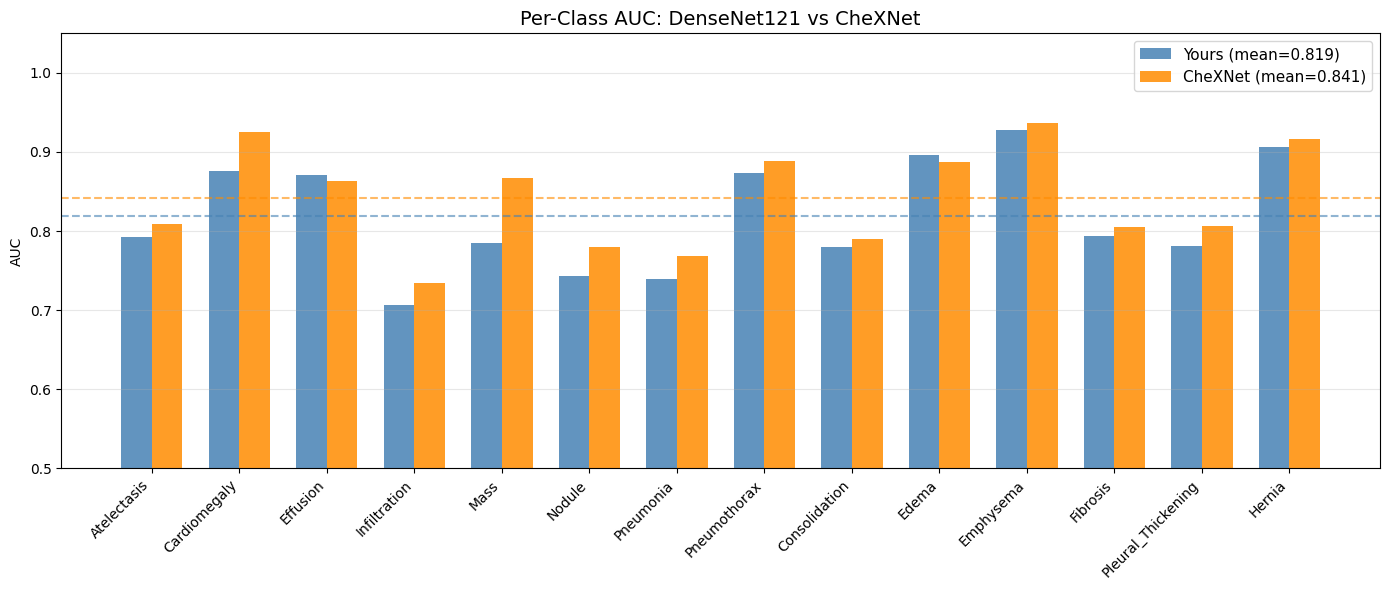

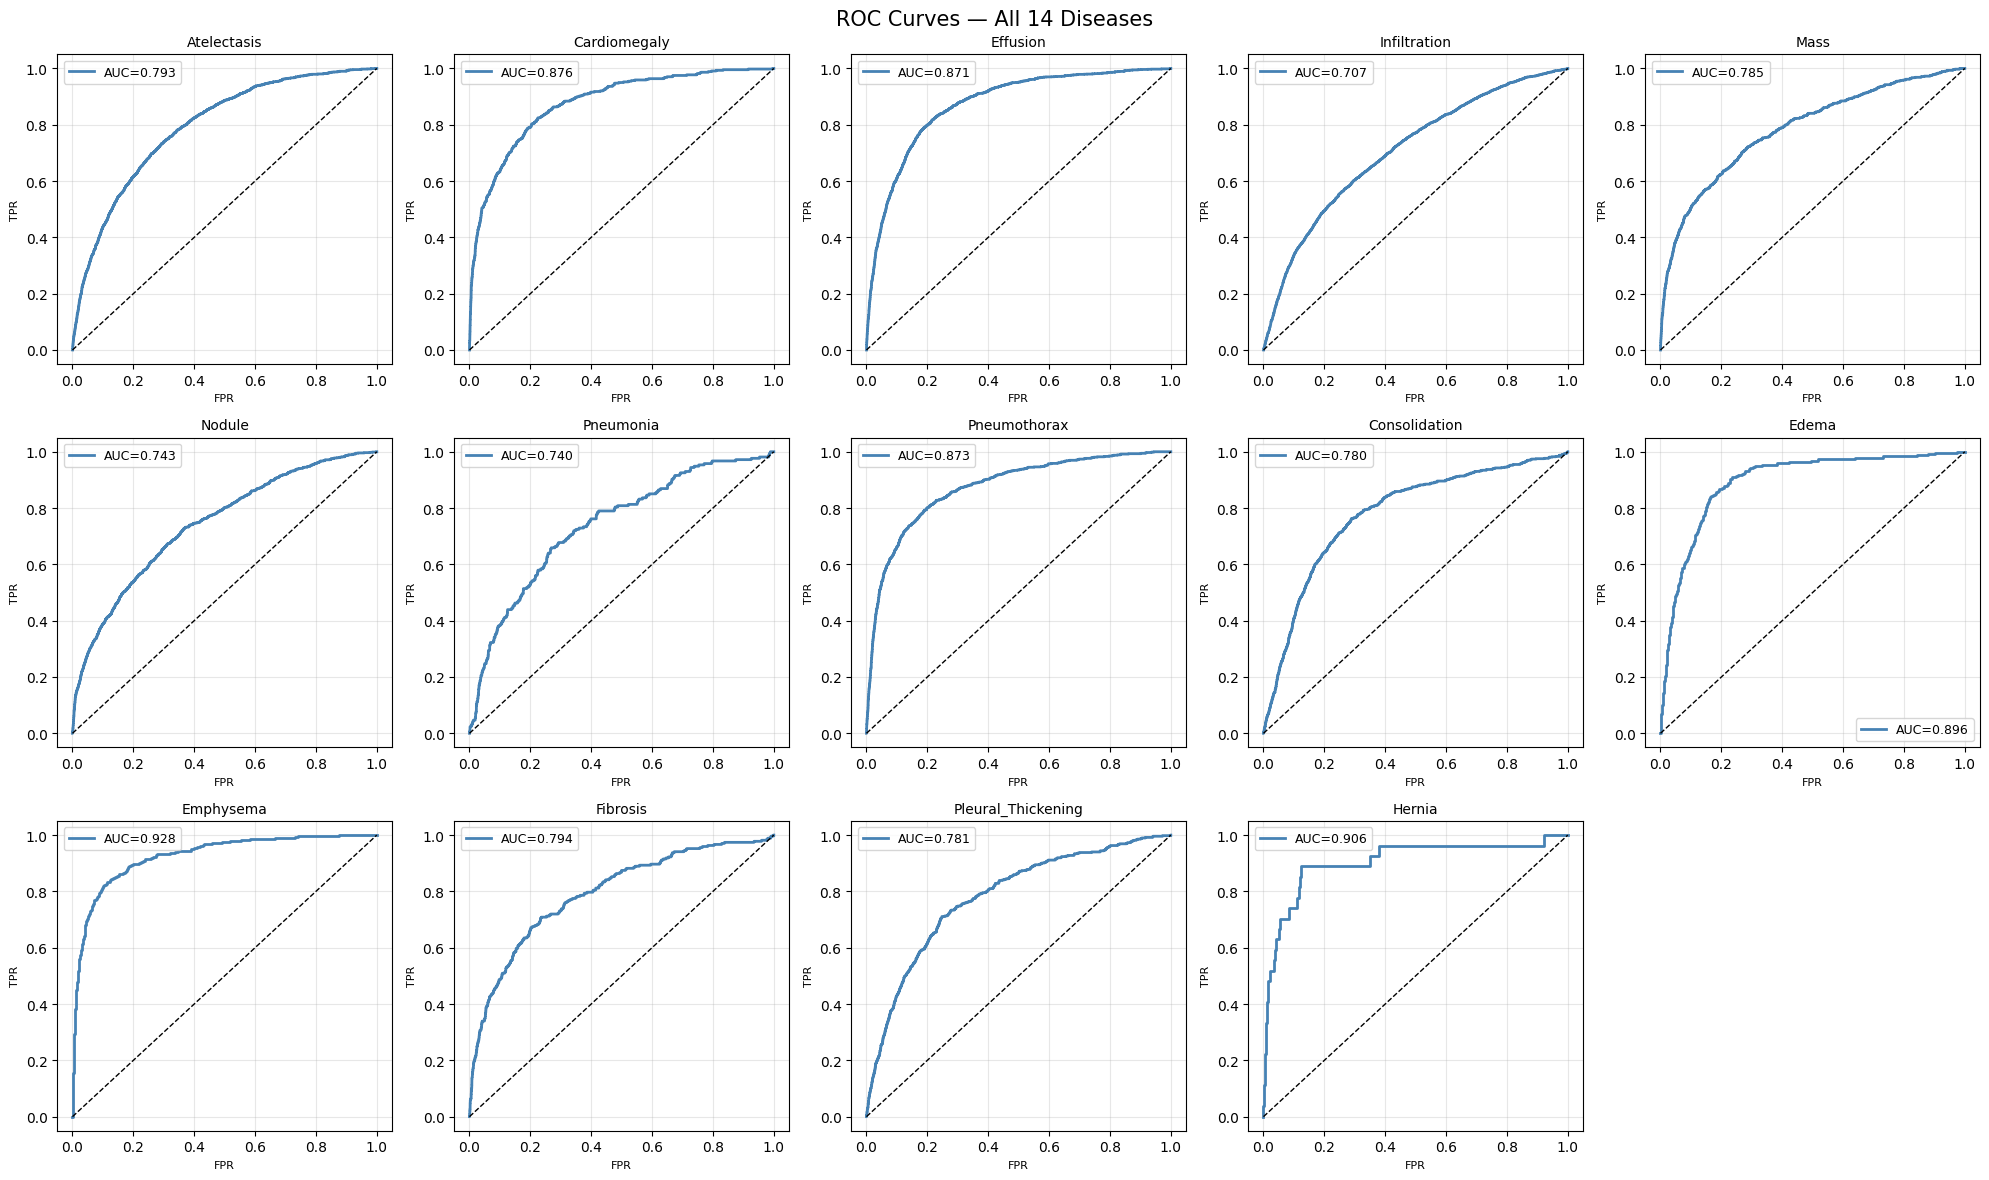

Plots saved.


In [17]:
# ============================================================
# CELL 19 — Plots (AUC comparison + ROC curves)
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np

# 1. AUC comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(CLASSES))
width = 0.35
your_aucs    = [auc_scores.get(c, 0) for c in CLASSES]
chexnet_aucs = [CHEXNET_AUCS.get(c, 0) for c in CLASSES]

ax.bar(x - width/2, your_aucs,    width, label=f'Yours (mean={mean_auc:.3f})',
       color='steelblue', alpha=0.85)
ax.bar(x + width/2, chexnet_aucs, width, label='CheXNet (mean=0.841)',
       color='darkorange', alpha=0.85)
ax.axhline(mean_auc, color='steelblue',  ls='--', alpha=0.6)
ax.axhline(0.8414,   color='darkorange', ls='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC')
ax.set_title('Per-Class AUC: DenseNet121 vs CheXNet', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/auc_comparison.png', dpi=150)
plt.show()

# 2. ROC curves (14 diseases)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, cls in enumerate(CLASSES):
    if all_labels[:, i].sum() == 0:
        axes[i].set_visible(False)
        continue
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
    axes[i].plot(fpr, tpr, color='steelblue', lw=2,
                 label=f'AUC={auc_scores.get(cls, 0):.3f}')
    axes[i].plot([0,1],[0,1],'k--',lw=1)
    axes[i].set_title(cls, fontsize=10)
    axes[i].set_xlabel('FPR', fontsize=8)
    axes[i].set_ylabel('TPR', fontsize=8)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
axes[14].set_visible(False)
plt.suptitle('ROC Curves — All 14 Diseases', fontsize=15)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/roc_curves.png', dpi=150)
plt.show()
print("Plots saved.")

Grad-CAM target layer : conv5_block16_2_conv
Grad model output shapes: (None, 10, 10, 32), (None, 10, 10, 1024)
Visualising classes: ['Cardiomegaly', 'Effusion', 'Pneumothorax', 'Atelectasis']
✓ Cardiomegaly         pred=0.702  heatmap range=[0.000, 1.000]
✓ Effusion             pred=0.541  heatmap range=[0.000, 1.000]
✓ Pneumothorax         pred=0.428  heatmap range=[0.000, 1.000]
✓ Atelectasis          pred=0.610  heatmap range=[0.000, 1.000]


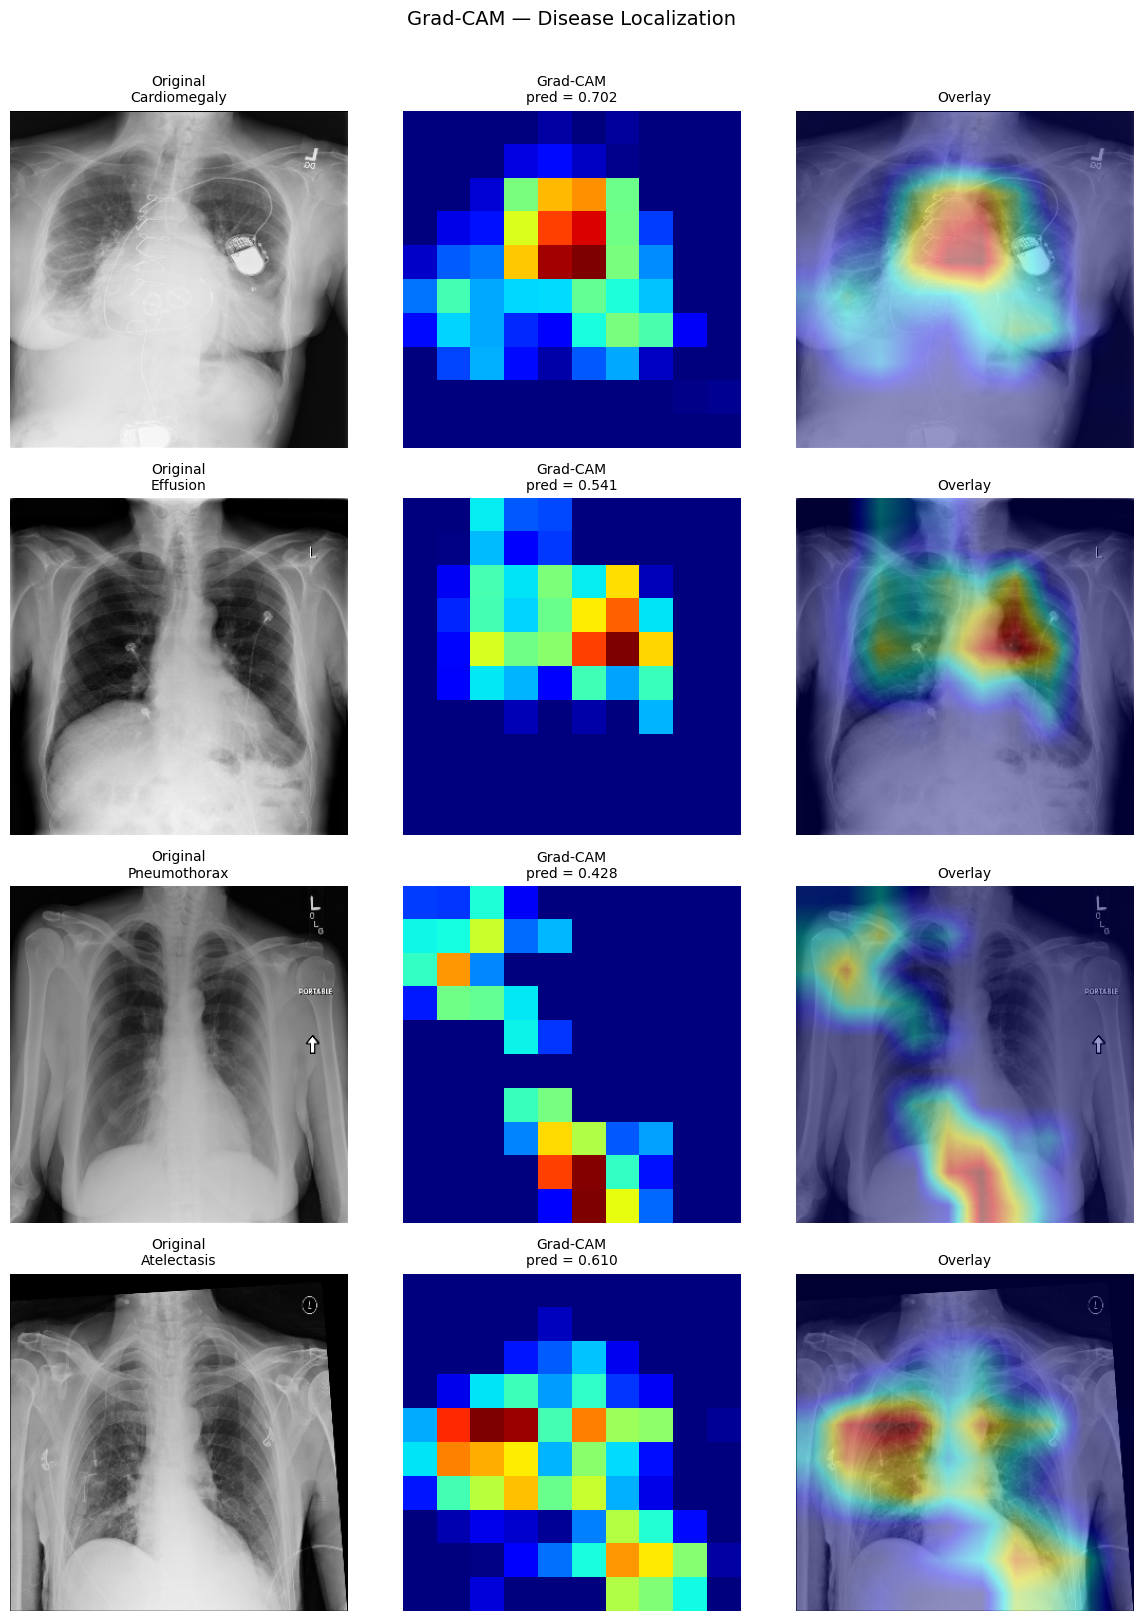


Saved: /kaggle/working/outputs/gradcam.png
All outputs: ['roc_curves.png', 'phaseC_ep5.keras', 'phaseC_ep8.keras', 'auc_comparison.png', 'phaseC_ep11.keras', 'best_model_phaseC.keras', 'labels_per_image.png', 'preprocessing_verification.png', 'disease_distribution.png', 'gradcam.png', 'cooccurrence_matrix.png', 'normal_vs_disease.png', 'final_results.json', 'sample_images.png']


In [22]:
# ============================================================
# CELL 20 — Grad-CAM Visualization (fixed)
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

os.makedirs('/kaggle/working/outputs', exist_ok=True)

densenet  = eval_model.get_layer('densenet121')
last_conv = 'conv5_block16_2_conv'

# Grad model: outputs (conv feature map, densenet output)
grad_model = tf.keras.Model(
    inputs  = densenet.input,
    outputs = [densenet.get_layer(last_conv).output, densenet.output]
)
print(f"Grad-CAM target layer : {last_conv}")
print(f"Grad model output shapes: "
      f"{grad_model.output[0].shape}, {grad_model.output[1].shape}")


def get_gradcam(img_tensor, class_idx):
    """
    Returns a 2D numpy heatmap of shape (H, W) in range [0, 1].
    img_tensor: shape (1, 320, 320, 3)
    """
    with tf.GradientTape() as tape:
        conv_out, base_out = grad_model(img_tensor, training=False)
        tape.watch(conv_out)

        # Manually pass through head layers
        x = eval_model.get_layer('gap')(base_out)
        x = eval_model.get_layer('head_bn')(x, training=False)
        x = eval_model.get_layer('drop1')(x, training=False)
        x = eval_model.get_layer('fc1')(x)
        x = eval_model.get_layer('fc_bn')(x, training=False)
        x = eval_model.get_layer('drop2')(x, training=False)
        preds = eval_model.get_layer('predictions')(x)
        score = preds[:, class_idx]

    grads  = tape.gradient(score, conv_out)   # (1, H, W, C)

    if grads is None:
        raise ValueError("Gradients are None — layer may not be in the graph")

    # Global average pool gradients over spatial dims → (C,)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    # Weighted sum of feature maps
    conv_np = conv_out[0].numpy()                     # (H, W, C)
    pool_np = pooled.numpy()                          # (C,)
    heatmap = np.dot(conv_np, pool_np)                # (H, W)

    # ReLU + normalize
    heatmap = np.maximum(heatmap, 0)
    vmax    = heatmap.max()
    if vmax < 1e-8:
        # Flat heatmap — return uniform map rather than crashing
        heatmap = np.ones_like(heatmap) * 0.5
    else:
        heatmap = heatmap / vmax

    # Ensure float32 2D array — cv2.resize requires this
    heatmap = heatmap.astype(np.float32)
    assert heatmap.ndim == 2, f"Expected 2D heatmap, got shape {heatmap.shape}"
    return heatmap


def make_overlay(img_disp, heatmap):
    """
    img_disp : (320, 320, 3) float in [0, 1]
    heatmap  : (H, W) float in [0, 1]
    Returns  : (320, 320, 3) uint8 overlay
    """
    # Resize heatmap to 320x320 using numpy/tf (no cv2 dependency for resize)
    h_resized = tf.image.resize(
        heatmap[..., np.newaxis], [320, 320]
    ).numpy()[..., 0]                                   # (320, 320)

    # Apply JET colormap via cv2
    h_uint8  = np.uint8(255 * h_resized)
    h_color  = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
    h_color  = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)  # (320, 320, 3)

    img_uint8 = np.uint8(255 * np.clip(img_disp, 0, 1))
    overlay   = cv2.addWeighted(img_uint8, 0.6, h_color, 0.4, 0)
    return overlay


# ── Sample images ─────────────────────────────────────────────────────────────
sample_classes = ['Cardiomegaly', 'Effusion', 'Pneumothorax', 'Atelectasis']

# Verify all classes exist
sample_classes = [c for c in sample_classes if c in CLASSES]
print(f"Visualising classes: {sample_classes}")

fig, axes = plt.subplots(len(sample_classes), 3, figsize=(12, 4 * len(sample_classes)))
if len(sample_classes) == 1:
    axes = axes[np.newaxis, :]   # ensure 2D indexing works

for row, cls_name in enumerate(sample_classes):
    cls_idx = CLASSES.index(cls_name)

    # Find a positive sample
    pos_rows = test_df[test_df[cls_name] == 1] if 'test_df' in dir() \
               else val_df[val_df[cls_name] == 1]
    if len(pos_rows) == 0:
        print(f"No positives for {cls_name} — skipping")
        for ax in axes[row]:
            ax.axis('off')
        continue

    img_path = pos_rows.iloc[0]['image_path']

    # Load and preprocess
    raw  = tf.io.read_file(img_path)
    raw  = tf.image.decode_png(raw, channels=3)
    raw  = tf.image.resize(raw, [320, 320])
    disp = (raw.numpy() / 255.0).astype(np.float32)    # display copy
    proc = tf.keras.applications.densenet.preprocess_input(
               tf.cast(raw, tf.float32))
    t    = tf.expand_dims(proc, 0)                      # (1, 320, 320, 3)

    # Prediction score
    pred_all = eval_model(t, training=False).numpy()[0]
    pred     = float(pred_all[cls_idx])

    try:
        heatmap = get_gradcam(t, cls_idx)
        overlay = make_overlay(disp, heatmap)

        axes[row, 0].imshow(disp, cmap='gray')
        axes[row, 0].set_title(f'Original\n{cls_name}', fontsize=10)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[row, 1].set_title(f'Grad-CAM\npred = {pred:.3f}', fontsize=10)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay', fontsize=10)
        axes[row, 2].axis('off')

        print(f"✓ {cls_name:<20} pred={pred:.3f}  "
              f"heatmap range=[{heatmap.min():.3f}, {heatmap.max():.3f}]")

    except Exception as e:
        print(f"✗ Grad-CAM failed for {cls_name}: {e}")
        for ax in axes[row]:
            ax.axis('off')
            ax.set_title(f'{cls_name}\nFailed: {str(e)[:40]}', fontsize=8)

plt.suptitle('Grad-CAM — Disease Localization', fontsize=14, y=1.01)
plt.tight_layout()

out_path = '/kaggle/working/outputs/gradcam.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {out_path}")
print("All outputs:", os.listdir('/kaggle/working/outputs'))